# Main Quest — 기존 Transformer를 GPT-1 구조로 변경하기

## 1. 연구 목적

이전 Exploration에서는 한국어 Q-A 데이터를 이용하여
Encoder-Decoder Transformer 기반 챗봇을 구현했다.

이번 Quest에서는 해당 모델을 기준선으로 삼아,
「Improving Language Understanding by Generative Pre-Training」에서 제안한
GPT-1의 **generative pre-training 구조**를 반영하도록 모델을 변경한다.

이번 실험의 범위는 GPT-1 논문의 두 단계 중 **Unsupervised Pre-training 단계까지**로 제한한다.

따라서 목표는

1. 기존 Encoder-Decoder 구조에서 어떤 블록을 제거해야 하는가?
2. GPT-1 Decoder-only 구조에서 어떤 블록을 유지·교체해야 하는가?
3. Q-A 데이터를 어떻게 하나의 causal language modeling sequence로 변환해야 하는가?
4. 다음 토큰 예측 학습이 실제로 수렴하는가?
5. 학습된 모델이 입력 prompt에 이어 새로운 token을 생성할 수 있는가?

를 직접 구현하고 검증하는 것.


## 2. 기존 Transformer → GPT-1 블록 변경 다이어그램

### 기존 한국어 Transformer 챗봇


```
Question
│
├─ Token Embedding
├─ Sinusoidal Positional Encoding
│
▼
┌──────────────────────────────┐
│ Encoder × 2                  │
│                              │
│ Self-Attention               │
│ → Residual + LayerNorm       │
│ → FFN(ReLU)                  │
│ → Residual + LayerNorm       │
└──────────────┬───────────────┘
               │ Encoder Output (K, V)
               │
               ▼
Answer[:-1]
│
▼
┌──────────────────────────────┐
│ Decoder × 2                  │
│                              │
│ Masked Self-Attention        │
│ → Residual + LayerNorm       │
│                              │
│ Cross-Attention              │◀── Encoder Output
│ → Residual + LayerNorm       │
│                              │
│ FFN(ReLU)                    │
│ → Residual + LayerNorm       │
└──────────────┬───────────────┘
               │
               ▼
        Vocabulary Linear
               │
               ▼
          Answer[1:]
```


### 변경한 GPT-1 구조



```
"질문 : Q 답변 : A"
│
▼
SentencePiece BPE
│
▼
Token IDs
│
├─ Token Embedding W_e
│
└─ Learned Position Embedding W_p
        │
        ▼
   h₀ = U W_e + W_p
        │
        ▼
┌──────────────────────────────┐
│ GPT-1 Transformer Block      │
│                              │
│ Masked Multi-Head            │
│ Self-Attention               │
│ → Residual + LayerNorm       │
│                              │
│ FFN(GELU)                    │
│ → Residual + LayerNorm       │
└──────────────┬───────────────┘
               │
              ×12
               │
               ▼
        Final Hidden State
               │
               ▼
             W_eᵀ
        (Weight Tying)
               │
               ▼
     Vocabulary Logits 8,000
               │
               ▼
       Next-token Prediction
```




## 3. 핵심 변화

기존 Transformer에서는 질문을 Encoder가 읽고,
Decoder가 Cross-Attention을 통해 질문 정보를 참조하면서 답변을 생성했다.

GPT-1에서는 질문과 답변을 별도로 처리하지 않는다.

`질문 : Q 답변 : A`

를 하나의 연속 token sequence로 변환한 뒤,
현재 위치 이전의 모든 token만을 이용하여 다음 token을 예측한다.

따라서 Encoder와 Cross-Attention이 제거되고,
모든 Transformer Block은 causal Masked Self-Attention만을 사용한다.

## 4. 아키텍처 및 학습 방식 변경사항

| 구분 | 기존 Transformer 챗봇 | GPT-1 구현 | 변경 이유 |
|---|---|---|---|
| 기본 구조 | Encoder-Decoder | Decoder-only | GPT-1 generative LM 구조 반영 |
| 입력 | Question / Answer 분리 | Q+A 단일 sequence | 하나의 contiguous causal context 구성 |
| Encoder | 사용 | 제거 | 모든 context가 하나의 sequence 안에 존재 |
| Cross-Attention | 사용 | 제거 | 참조할 별도 Encoder output이 없음 |
| Self-Attention | Encoder/Decoder별 사용 | 모든 Block에서 Masked Self-Attention | 미래 token 참조 방지 |
| Position 정보 | Sinusoidal Encoding | Learned Position Embedding | GPT-1의 \(W_p\) 구현 |
| Position 학습 | 고정 | 학습 가능 | gradient를 통해 위치 표현 학습 |
| FFN 활성화 | ReLU | GELU | GPT-1 모델 설정 반영 |
| Layer 구조 | Encoder 2 + Decoder 2 | GPT Block 12 | GPT-1 architecture 반영 |
| hidden dimension | 256 | 768 | GPT-1 architecture 반영 |
| Attention heads | 8 | 12 | GPT-1 architecture 반영 |
| Head dimension | 32 | 64 | \(768 / 12\) |
| FFN dimension | 512 | 3072 | GPT-1 architecture 반영 |
| 출력 projection | 독립 Linear | \(W_e^T\) Weight Tying | 입력 embedding과 출력 weight 공유 |
| 학습 문제 | Seq2Seq | Causal Language Modeling | 모든 위치에서 next-token prediction |
| Shift | Answer만 shift | Q+A 전체 sequence shift | causal LM objective 구현 |
| 주요 평가 | Loss / Token Accuracy | LM Loss / Perplexity | 언어모델 사전학습 평가 |

### GPT-1 논문에서 구조적으로 유지한 요소

- Decoder-only Transformer
- 12 Transformer Blocks
- `d_model = 768`
- Multi-Head Attention 12 heads
- `d_ff = 3072`
- GELU
- Learned Position Embedding
- Causal Language Modeling
- Token Embedding / LM Head Weight Tying
- Dropout 0.1
- Linear Warm-up 이후 Cosine Learning Rate Decay

### 현재 한국어 데이터 조건에 맞춰 조정한 요소

| 항목 | GPT-1 논문 | 본 실험 |
|---|---:|---:|
| Corpus | BooksCorpus | 한국어 Q-A 11,750 pairs |
| Vocabulary | 약 40K BPE | SentencePiece BPE 8K |
| Context length | 512 | 전체 sequence 45 / model input 44 |
| Batch | 64 | 64, T4 Backward 검증 후 확정 |
| Epoch | 100 | 10 |
| Warm-up | 2,000 updates | 100 updates |

## 5. 데이터 전처리 및 GPT-1 입력 구성

### 원본 데이터

- 원본 Q-A: 11,823 pairs
- 결측값: 0
- 빈 문자열: 0
- Exact Q-A duplicates: 73

동일 Q-A 73건을 제거하여 최종 11,750개 dialogue를 사용함

### 최소 전처리

Causal Language Model에서는 원문 자체가 학습 대상이므로
기존 챗봇 프로젝트보다 강한 문자 정제를 수행하지 않음

적용:
- Unicode NFC normalization
- 연속 whitespace 정리
- Exact Q-A duplicate 제거

보존:
- 한글 자모 (`ㅋㅋ`, `ㅠㅠ`, `ㅜㅜ`)
- 영문 (`SNS`, `PPL`, `SD`)
- 숫자
- 문장부호

### Train / Validation Split

동일한 질문이 Train과 Validation 양쪽에 포함되는 것을 방지하기 위해
Q를 group으로 지정하여 약 90:10으로 분할했음

- Train: 10,573
- Validation: 1,177
- Q overlap: 0

`label` 컬럼은 데이터 명세 확인에만 사용하였으며
split, tokenizer, 모델 학습에는 사용하지 않음

### GPT-1용 직렬화

기존:

Question → Encoder  
Answer → Decoder

변경:

`질문 : Q 답변 : A`

각 Q-A pair를 하나의 연속된 dialogue sequence로 변환함

## 6. Tokenization 및 Context Length 결정

Train dialogue만을 이용하여 SentencePiece BPE tokenizer를 학습시켰다.

- Vocabulary: 8,000
- PAD: 0
- UNK: 1
- EOS: 2

Validation UNK:

- UNK tokens: 23
- UNK rate: 0.1253%

Dialogue 전체에 EOS를 추가하여 token length를 분석한 결과:

| 통계 | Token Length |
|---|---:|
| Mean | 16.25 |
| Median | 16 |
| 90% | 21 |
| 95% | 23 |
| 99% | 28 |
| Max | 45 |

모든 데이터를 truncation 없이 보존할 수 있는 최소값을 사용하기 위해:

`MAX_SEQUENCE_LEN = 45`

로 결정했다.

Causal Language Modeling에서는 전체 sequence를 한 칸 shift하므로
실제 Transformer 입력 길이는:

`MODEL_INPUT_LEN = 44`

가 된다.

## 7. GPT-1 모델 구성 및 단위 검증

최종 모델:

- Vocabulary: 8,000
- Transformer Blocks: 12
- Hidden Dimension: 768
- Attention Heads: 12
- Head Dimension: 64
- FFN Dimension: 3,072
- Dropout: 0.1
- Total Parameters: 91,232,256

### Learned Position Embedding

입력 블록은 논문의 다음 식을 구현했다.

```
h_0 = UW_e + W_p
```

실제 검증 결과:

- Token Embedding: `[64, 44, 768]`
- Position Embedding: `[1, 44, 768]`
- `h₀`: `[64, 44, 768]`
- Position Embedding `requires_grad=True`
- `h₀ == Token Embedding + Position Embedding`: True

### GPT-1 Transformer Block

실제 Batch를 이용한 단일 Block 검증:

- Input: `[64, 44, 768]`
- Output: `[64, 44, 768]`
- Finite: True
- Shape Check: PASS

### Weight Tying

Token Embedding과 LM Head가 동일한 parameter를 사용하는지 확인했다.

- Token Embedding: `[8000, 768]`
- LM Head: `[8000, 768]`
- Same Parameter: True
- Same Memory: True

### 전체 Forward

- Input IDs: `[2, 44]`
- Final Hidden States: `[2, 44, 768]`
- Vocabulary Logits: `[2, 44, 8000]`
- Finite: True

초기 Language Modeling Loss:

`9.0793`

로 나왔다.

## 8. 학습 설정

### Hardware 검증

Batch Size 64에서 실제 Forward + Backward 수행:

- Loss: 9.1228
- Gradient Norm: 8.1138
- All Gradients Finite: True
- Peak GPU Memory: 2.41 GB

Tesla T4에서 안정적으로 학습 가능한 것을 확인,
Batch Size 64를 최종 확정

### Optimizer

- Optimizer: AdamW
- Maximum LR: 2.5e-4
- Weight Decay: 0.01

Optimizer Step 후 실제 parameter 변화:

- Mean Weight Change: 0.00017048
- Optimizer Update Check: PASS

### Learning Rate Schedule

- Epochs: 10
- Steps / Epoch: 166
- Total Updates: 1,660
- Warm-up Steps: 100
- Warm-up Ratio: 6.02%
- Schedule: Linear Warm-up → Cosine Decay

GPT-1 원논문의 scheduler 형태는 유지하되,
본 corpus의 전체 update 수가 훨씬 작으므로 warm-up 길이를 100 step으로 조정

## 9. 사전학습 결과

### 학습 전

- Validation Loss: 9.1283
- Validation Perplexity: 9212.68

### Epoch 결과

| Epoch | Train Loss | Val Loss | Train PPL | Val PPL |
|---:|---:|---:|---:|---:|
| 1 | 5.7275 | 5.1264 | 307.20 | 168.41 |
| 2 | 4.8121 | 4.6702 | 122.99 | 106.72 |
| 3 | 4.2494 | 4.3025 | 70.06 | 73.89 |
| 4 | 3.7250 | 4.0737 | 41.47 | 58.77 |
| 5 | 3.2200 | 3.9131 | 25.03 | 50.05 |
| 6 | 2.7367 | 3.8266 | 15.44 | 45.91 |
| 7 | 2.3093 | 3.7896 | 10.07 | 44.24 |
| **8** | **1.9939** | **3.7739** | **7.34** | **43.55** |
| 9 | 1.8084 | 3.7769 | 6.10 | 43.68 |
| 10 | 1.7300 | 3.7783 | 5.64 | 43.74 |

### 최적 모델

- Best Epoch: **8**
- Best Validation Loss: **3.7739**
- Best Validation Perplexity: **43.55**

학습 전 Validation Perplexity 9212.68에서
Best Epoch의 43.55까지 크게 감소함.

Epoch 8 이후에도 Train Loss는 계속 감소했지만
Validation Loss는 소폭 증가함.

따라서 Epoch 8 부근에서 일반화 성능이 포화되었으며,
Epoch 9부터 초기 과적합 징후가 나타남.

최종 모델은 Validation LM Loss가 가장 낮은 Epoch 8 checkpoint를 사용했다.

## 10. Prompt 기반 Autoregressive Generation

학습 당시와 동일한 형식으로:

`질문 : 새로운 질문 답변 :`

을 prompt로 입력하고 Greedy Decoding으로 다음 token을 반복 생성했다.

### 생성 결과

| 질문 | 생성 답변 | 정성 평가 |
|---|---|---|
| 안녕? | 잘 견뎌봐요. | 문장은 자연스럽지만 인사 맥락은 약함 |
| 땡큐우~ | 저도 해보고 싶네요. | 한국어 생성 성공, 의미 연결은 약함 |
| 오늘 너무 습하다 | 좋은 생각 하지 마세요. | 맥락 부적합 |
| 친구랑 안 싸웠음 | 사람 고쳐쓰는 거 아니에요. | 갈등 관련 표현에 반응했지만 부정 의미를 놓침 |
| 여행 잘 다녀왔음 | 좋은 생각이에요. | 약하게 관련됨 |
| 좋아하는 사람 질문 좀 그만하자? | 마음이 복잡할 수 있어요. | 비교적 자연스러운 맥락 |

### 결과 해석

모든 prompt에서 한국어 형식의 출력이 생성되었으며,
Decoder-only 구조의 autoregressive next-token generation이 정상적으로 작동됐다.

그러나 문법적으로 자연스러운 문장을 생성하는 능력과
질문의 세부 의미를 정확하게 이해하는 능력 사이에는 차이가 있었다.

특히 부정 표현이나 새로운 문맥에서는 의미 연결이 부족한 사례가 나타났다.

이번 실험은 GPT-1의 supervised fine-tuning 단계가 아닌
generative pre-training 구조까지만을 대상으로 하므로,
이 결과는 downstream 챗봇 성능이라기보다
사전학습된 causal language model이 정상적으로 작동하는지를 확인하는 정성 평가로 사용했다.

In [2]:
# ============================================================
# 0-1. Google Drive 연동과 경로 설정
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

COLAB_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks"
)

PROJECT_DIR = COLAB_DIR / "Main_Quest_GPT1"

DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"

for path in [
    PROJECT_DIR,
    DATA_DIR,
    MODEL_DIR,
    OUTPUT_DIR
]:
    path.mkdir(
        parents=True,
        exist_ok=True
    )

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR   :", DATA_DIR)
print("MODEL_DIR  :", MODEL_DIR)
print("OUTPUT_DIR :", OUTPUT_DIR)

Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/Colab Notebooks/Main_Quest_GPT1
DATA_DIR   : /content/drive/MyDrive/Colab Notebooks/Main_Quest_GPT1/data
MODEL_DIR  : /content/drive/MyDrive/Colab Notebooks/Main_Quest_GPT1/models
OUTPUT_DIR : /content/drive/MyDrive/Colab Notebooks/Main_Quest_GPT1/outputs


In [3]:
# ============================================================
# 0-2. 환경 확인과 설정
# ============================================================

import sys
import platform
import importlib.util
import subprocess

# 필요한 경우에만 설치
if importlib.util.find_spec("sentencepiece") is None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "sentencepiece"
    ])

import torch
import pandas as pd
import sentencepiece as spm

print("=" * 60)
print("Python        :", sys.version.split()[0])
print("Platform      :", platform.platform())
print("PyTorch       :", torch.__version__)
print("SentencePiece :", spm.__version__)
print("CUDA usable   :", torch.cuda.is_available())

if torch.cuda.is_available():
    print(
        "GPU           :",
        torch.cuda.get_device_name(0)
    )

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device        :", DEVICE)
print("=" * 60)

Python        : 3.12.13
Platform      : Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch       : 2.11.0+cu128
SentencePiece : 0.2.2
CUDA usable   : True
GPU           : Tesla T4
Device        : cuda


## Step 1. 원본 챗봇 데이터 다시 불러오기!
---

In [4]:
# ============================================================
# Step 1-1. Load Raw Chatbot Dataset
# GPT-1 실험상 특징:
# label은 데이터 설명용으로만 확인하고 학습에는 사용하지 않는다.
# ============================================================

from urllib.request import urlretrieve

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "songys/Chatbot_data/master/ChatbotData.csv"
)

DATA_PATH = DATA_DIR / "ChatbotData.csv"

if not DATA_PATH.exists():
    urlretrieve(
        DATA_URL,
        str(DATA_PATH)
    )
    print("다운로드 완료")
else:
    print("이미 파일이 존재합니다.")

df_raw = pd.read_csv(DATA_PATH)

print("=" * 70)
print("[Raw Dataset]")
print("Path       :", DATA_PATH)
print("Shape      :", df_raw.shape)
print("Columns    :", df_raw.columns.tolist())
print("Duplicates :", df_raw.duplicated(subset=["Q", "A"]).sum())
print("=" * 70)

display(df_raw.head())

이미 파일이 존재합니다.
[Raw Dataset]
Path       : /content/drive/MyDrive/Colab Notebooks/Main_Quest_GPT1/data/ChatbotData.csv
Shape      : (11823, 3)
Columns    : ['Q', 'A', 'label']
Duplicates : 73


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [5]:
# ============================================================
# Step 1-2. 데이터 품질 확인
# ============================================================


print("[Missing Values]")
print(df_raw[["Q", "A", "label"]].isna().sum())

print("\n[Empty String]")
print(
    "Q:",
    df_raw["Q"].astype(str).str.strip().eq("").sum()
)
print(
    "A:",
    df_raw["A"].astype(str).str.strip().eq("").sum()
)

print("\n[Exact Q-A Duplicates]")
duplicate_count = df_raw.duplicated(
    subset=["Q", "A"]
).sum()

print(duplicate_count)

print("\n[Raw Character Length]")
print(
    df_raw[["Q", "A"]]
    .astype(str)
    .apply(lambda col: col.str.len())
    .describe(
        percentiles=[0.5, 0.9, 0.95, 0.99]
    )
)

print("\n[Label — 학습에 쓰려는 게 아니예요. 데이터 명세 확인해보는거예요~]")
print(df_raw["label"].value_counts())

[Missing Values]
Q        0
A        0
label    0
dtype: int64

[Empty String]
Q: 0
A: 0

[Exact Q-A Duplicates]
73

[Raw Character Length]
                  Q             A
count  11823.000000  11823.000000
mean      12.879049     15.015140
std        6.167467      6.701835
min        1.000000      1.000000
50%       12.000000     14.000000
90%       21.000000     23.000000
95%       25.000000     27.000000
99%       32.000000     37.000000
max       56.000000     76.000000

[Label — 학습에 쓰려는 게 아니예요. 데이터 명세 확인해보는거예요~]
label
0    5290
1    3570
2    2963
Name: count, dtype: int64


In [6]:
# ============================================================
# Step 1-3. 실제 Q-A 사례를 보고 데이터 특성 확인해보기
# ============================================================

sample_df = df_raw.sample(
    n=10,
    random_state=42
)[["Q", "A"]]

display(sample_df)

,Q,A
8169,죽을거 같네,나쁜 생각 하지 마세요.
900,내일 시험이야,컨디션 조절 하세요.
8075,정말.내 자신이 싫다,자신은 사랑해주세요.
7625,이별후 네달째,바쁘게 살면서 잊어가요.
2816,쌍커풀 해볼까,눈은 기본이죠.
5860,내 생각 하나만 바꾸면 편할텐데.,하나 바꾸는 게 힘들지요.
6939,어떻게 살아가야 할까,태연하게 시작해보세요.
1935,발 아파,맥주병 같은 걸로 살살 문질러 주세요
10181,썸 타는 것도 귀찮아.,그냥 사귀세요.
11198,좋아하는 애랑 전화하면,즐거울 거예요.


- GPT-1 원논문의 512 tokens를 그대로 가져오는 것은 이번 데이터에는 맞지 않을 가능성이 매우 높음
- 원논문은 BooksCorpus에서 무작위로 뽑은 연속된 512-token sequence를 사용했음
- 저는 Q와 A를 붙이고 role 표현까지 추가한 후에 토큰 길이 측정해서 Max 길이를 결정하겠습니다.

## Step 2. 데이터 전처리하기
---

이번에는 Q가 인코더 들어가고 A[:-1]이 디코더, A[1:]이 레이블이었던 것과 달리 모델은 모든 위치에서 그저 "다음에 무엇이 올까?"만 푸는 것.

```
Q + A
  │
  ▼
"질문 : Q 답변 : A"
  │
  ▼
SentencePiece
  │
  ▼
[t0, t1, t2, t3, ..., tn]
  │
  ├── Input  = [t0, t1, ..., t(n-1)]
  └── Label  = [t1, t2, ..., tn]
```



In [7]:
# ============================================================
# Step 2-1. 전처리 전에 일단 특수 표현을 확인해보기
# GPT-1 causal LM에서는 원문 자체가 학습 대상이므로
# 삭제하기 전에 어떤 표현들이 있는지 먼저 확인한다.
# ============================================================

import re
import unicodedata
from collections import Counter


# ------------------------------------------------------------
# 1. Q 자체 중복 / A 자체 중복 확인
# ------------------------------------------------------------

print("=" * 70)
print("[Duplicate Structure]")

print(
    "Rows with duplicated Q:",
    df_raw.duplicated(
        subset=["Q"],
        keep=False
    ).sum()
)

print(
    "Unique Q:",
    df_raw["Q"].nunique()
)

print(
    "Unique A:",
    df_raw["A"].nunique()
)


# 동일 질문에 서로 다른 답변이 몇 개 존재하는지
q_answer_counts = (
    df_raw.groupby("Q")["A"]
    .nunique()
)

multi_answer_q = (
    q_answer_counts[
        q_answer_counts > 1
    ]
)

print(
    "Q with multiple different answers:",
    len(multi_answer_q)
)


# ------------------------------------------------------------
# 2. 문자 유형 확인
# ------------------------------------------------------------

all_text = (
    df_raw["Q"].astype(str)
    + " "
    + df_raw["A"].astype(str)
)

patterns = {
    "Hangul syllable":
        r"[가-힣]",

    "Korean jamo":
        r"[ㄱ-ㅎㅏ-ㅣ]",

    "English":
        r"[A-Za-z]",

    "Digit":
        r"[0-9]",

    "Basic punctuation":
        r"[.!?,~]"
}

print("\n[Rows containing each character type]")

for name, pattern in patterns.items():

    count = (
        all_text
        .str.contains(
            pattern,
            regex=True,
            na=False
        )
        .sum()
    )

    print(
        f"{name:20s}: {count:,}"
    )


# ------------------------------------------------------------
# 3. 아직 정의하지 않은 기타 문자 확인
# ------------------------------------------------------------

allowed_pattern = (
    r"[가-힣"
    r"ㄱ-ㅎ"
    r"ㅏ-ㅣ"
    r"A-Za-z"
    r"0-9"
    r"\s"
    r".,!?~"
    r"]"
)

other_chars = Counter()

for text in all_text:

    for ch in text:

        if not re.fullmatch(
            allowed_pattern,
            ch
        ):
            other_chars[ch] += 1


print("\n[Top Other Characters]")

for char, count in other_chars.most_common(30):

    print(
        repr(char),
        count
    )


# ------------------------------------------------------------
# 4. 자모가 포함된 실제 예시
# ------------------------------------------------------------

jamo_examples = df_raw[
    all_text.str.contains(
        r"[ㄱ-ㅎㅏ-ㅣ]",
        regex=True,
        na=False
    )
][["Q", "A"]].head(10)

print("\n[Jamo Examples]")
display(jamo_examples)


# ------------------------------------------------------------
# 5. 영문이 포함된 실제 예시
# ------------------------------------------------------------

english_examples = df_raw[
    all_text.str.contains(
        r"[A-Za-z]",
        regex=True,
        na=False
    )
][["Q", "A"]].head(10)

print("\n[English Examples]")
display(english_examples)

[Duplicate Structure]
Rows with duplicated Q: 317
Unique Q: 11662
Unique A: 7779
Q with multiple different answers: 85

[Rows containing each character type]
Hangul syllable     : 11,823
Korean jamo         : 78
English             : 42
Digit               : 415
Basic punctuation   : 11,714

[Top Other Characters]
"'" 9
';' 6
'…' 5
'-' 3
'%' 2
'_' 1

[Jamo Examples]


,Q,A
7,SNS 맞팔 왜 안하지ㅠㅠ,잘 모르고 있을 수도 있어요.
211,공무원 시험 힘들어ㅠㅠ,철밥통 되기가 어디 쉽겠어요.
1153,단둘이는 처음 만나는 날ㅋㅋ,서로를 아는 좋은 기회가 되겠네요.
2104,보일러 틀고 나갔어ㅠㅠ,이번달 난방비가 많이 나오겠네요.
2229,비트코인 ㅜㅜ,안타깝지만 잊어버리세요.
2936,안경 벗었는데 차이가 없어ㅋㅋ,이게 정상이죠.
5240,회식 좀 그만 했으면ㅜㅜ,가기 싫어도 가야겠죠.
5555,괜찮다가.갑자기 ㅠ,더 괜찮아 지려고 하는 과정일 거예요.
5630,그녀는 무슨 생각일까?ㅠ,그녀밖에 알 수가 없죠.
5723,꿈꾸니까 진짜 힘드네ㅜ,꿈이 웬수네요.



[English Examples]


,Q,A
4,PPL 심하네,눈살이 찌푸려지죠.
5,SD카드 망가졌어,다시 새로 사는 게 마음 편해요.
6,SD카드 안돼,다시 새로 사는 게 마음 편해요.
7,SNS 맞팔 왜 안하지ㅠㅠ,잘 모르고 있을 수도 있어요.
8,SNS 시간낭비인 거 아는데 매일 하는 중,시간을 정하고 해보세요.
9,SNS 시간낭비인데 자꾸 보게됨,시간을 정하고 해보세요.
10,SNS보면 나만 빼고 다 행복해보여,자랑하는 자리니까요.
754,남친 SNS에 내 사진 없어,신경쓰지 마세요.
762,남친이 SNS에 내 사진에 안 올려,신경쓰지 마세요.
1401,떨어뜨려서 핸드폰 액정 나갔어,as 맡기세요.


In [8]:
# ============================================================
# Step 2-2. 정규화를 최소로만 했을 때 중복이 어떻게 변하는지 체크
# 아직 확정 전처리가 아니라 비교용 실험
# ============================================================

def normalize_minimal(text):

    # Unicode 표현 방식 통일
    text = unicodedata.normalize(
        "NFC",
        str(text)
    )

    # 연속 whitespace만 하나로 정리
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


probe_df = df_raw.copy()

probe_df["Q_min"] = (
    probe_df["Q"]
    .map(normalize_minimal)
)

probe_df["A_min"] = (
    probe_df["A"]
    .map(normalize_minimal)
)


raw_duplicates = (
    df_raw
    .duplicated(
        subset=["Q", "A"]
    )
    .sum()
)

normalized_duplicates = (
    probe_df
    .duplicated(
        subset=["Q_min", "A_min"]
    )
    .sum()
)


print("=" * 70)
print("[Duplicate Comparison]")
print(
    "Raw exact duplicates       :",
    raw_duplicates
)
print(
    "After minimal normalization:",
    normalized_duplicates
)
print("=" * 70)

[Duplicate Comparison]
Raw exact duplicates       : 73
After minimal normalization: 73


In [9]:
# ============================================================
# Step 2-3. 다이얼로그 형식 더한 것 확인해보기
# ============================================================

preview_df = probe_df.copy()

preview_df["dialogue_text"] = (
    "질문 : "
    + preview_df["Q_min"]
    + " 답변 : "
    + preview_df["A_min"]
)

print("[Dialogue Preview]")

for text in (
    preview_df["dialogue_text"]
    .sample(
        n=10,
        random_state=42
    )
):

    print(
        "-",
        text
    )

[Dialogue Preview]
- 질문 : 죽을거 같네 답변 : 나쁜 생각 하지 마세요.
- 질문 : 내일 시험이야 답변 : 컨디션 조절 하세요.
- 질문 : 정말.내 자신이 싫다 답변 : 자신은 사랑해주세요.
- 질문 : 이별후 네달째 답변 : 바쁘게 살면서 잊어가요.
- 질문 : 쌍커풀 해볼까 답변 : 눈은 기본이죠.
- 질문 : 내 생각 하나만 바꾸면 편할텐데. 답변 : 하나 바꾸는 게 힘들지요.
- 질문 : 어떻게 살아가야 할까 답변 : 태연하게 시작해보세요.
- 질문 : 발 아파 답변 : 맥주병 같은 걸로 살살 문질러 주세요
- 질문 : 썸 타는 것도 귀찮아. 답변 : 그냥 사귀세요.
- 질문 : 좋아하는 애랑 전화하면 답변 : 즐거울 거예요.


next-token prediction 하나만 계속 반복하기 위한 처리.

이게 GPT-1의


```
P(ui​∣ui−k​,…,ui−1​)
```

를 Q-A 데이터에 적용한 셈이 됩니다~


## 데이터 사전 탐색 결과
원본 ChatbotData는 총 11,823개의 Q-A pair로 구성되어 있으며 결측값과 빈 문자열은 확인되지 않았다.

동일한 질문-답변 쌍 73건이 존재하여 학습/검증 분할 이전에 제거할 예정이다. 질문과 답변의 문자 길이 중앙값은 각각 12자, 14자로 짧은 대화가 주를 이루며, 99 percentile 역시 각각 32자와 37자였다.

따라서 GPT-1 원논문의 512-token sequence length를 그대로 적용하지 않고, Q-A를 하나의 dialogue sequence로 변환한 후 SentencePiece BPE 기준 token-length distribution을 측정하여 본 데이터에 적합한 최대 길이를 결정한다.

원본의 label은 데이터 구성 확인을 위해서만 조회하며 causal language modeling의 입력, 학습 objective 및 train/validation split에는 사용하지 않는다.

In [12]:
# ============================================================
# Step 2-4. 최소 정규화와 정확한, 완전히 같은 중복 제거
#
# GPT-1 변경사항:
# 기존 챗봇 전처리처럼 문자 종류를 강하게 제한하지 않고,
# causal LM이 원문 자체를 학습하도록 최소 정규화만 적용한다.
# ============================================================

import re
import unicodedata


def normalize_text(text):
    """
    Minimal normalization for causal language modeling.

    - Unicode NFC normalization
    - Collapse consecutive whitespace
    - Strip leading/trailing whitespace

    의미 있는 자모, 영문, 숫자, 문장부호는 보존한다.
    """

    text = unicodedata.normalize(
        "NFC",
        str(text)
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


df = df_raw.copy()

df["Q_clean"] = df["Q"].map(normalize_text)
df["A_clean"] = df["A"].map(normalize_text)


before = len(df)

df = (
    df
    .drop_duplicates(
        subset=["Q_clean", "A_clean"]
    )
    .reset_index(drop=True)
)

after = len(df)


print("=" * 70)
print("[Minimal Normalization + Deduplication]")
print("Before :", before)
print("After  :", after)
print("Removed:", before - after)

print("\nUnique Q:", df["Q_clean"].nunique())

print(
    "Q with multiple answers:",
    (
        df.groupby("Q_clean")["A_clean"]
        .nunique()
        .gt(1)
        .sum()
    )
)

print("=" * 70)

display(
    df[
        ["Q", "A", "Q_clean", "A_clean"]
    ].head()
)

[Minimal Normalization + Deduplication]
Before : 11823
After  : 11750
Removed: 73

Unique Q: 11662
Q with multiple answers: 85


,Q,A,Q_clean,A_clean
0,12시 땡!,하루가 또 가네요.,12시 땡!,하루가 또 가네요.
1,1지망 학교 떨어졌어,위로해 드립니다.,1지망 학교 떨어졌어,위로해 드립니다.
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,3박4일 놀러가고 싶다,여행은 언제나 좋죠.
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.
4,PPL 심하네,눈살이 찌푸려지죠.,PPL 심하네,눈살이 찌푸려지죠.


In [11]:
# ============================================================
# Step 2-5. Q단위 Train / Validation Split
#
# GPT-1 변경사항:
# label stratification을 제거한다.
#
# 같은 질문(Q)이 Train과 Validation 양쪽에 등장하여
# validation이 쉬워지는 것을 막기 위해 Q 단위로 분리한다.
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

SEED = 42

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.10,
    random_state=SEED
)

train_idx, val_idx = next(
    splitter.split(
        df,
        groups=df["Q_clean"]
    )
)

train_df = (
    df.iloc[train_idx]
    .reset_index(drop=True)
)

val_df = (
    df.iloc[val_idx]
    .reset_index(drop=True)
)


print("=" * 70)
print("[Group-aware Split]")
print("Train rows :", len(train_df))
print("Val rows   :", len(val_df))
print(
    "Train ratio:",
    f"{len(train_df) / len(df):.2%}"
)
print(
    "Val ratio  :",
    f"{len(val_df) / len(df):.2%}"
)

print("\nTrain unique Q:", train_df["Q_clean"].nunique())
print("Val unique Q  :", val_df["Q_clean"].nunique())


# ------------------------------------------------------------
# Leakage Check
# ------------------------------------------------------------

train_q = set(train_df["Q_clean"])
val_q = set(val_df["Q_clean"])

q_overlap = train_q & val_q

print(
    "\nQ overlap between Train / Validation:",
    len(q_overlap)
)

assert len(q_overlap) == 0

print("=" * 70)

[Group-aware Split]
Train rows : 10573
Val rows   : 1177
Train ratio: 89.98%
Val ratio  : 10.02%

Train unique Q: 10495
Val unique Q  : 1167

Q overlap between Train / Validation: 0


In [13]:
# ============================================================
# Step 2-6. Single Dialogue Sequence 생성
#
# GPT-1 변경사항:
# Encoder source / Decoder target 구조 제거
#
# Q와 A를 하나의 contiguous token sequence로 직렬화한다.
# ============================================================

def serialize_dialogue(question, answer):

    return (
        f"질문 : {question} "
        f"답변 : {answer}"
    )


train_df["dialogue_text"] = [
    serialize_dialogue(q, a)
    for q, a in zip(
        train_df["Q_clean"],
        train_df["A_clean"]
    )
]

val_df["dialogue_text"] = [
    serialize_dialogue(q, a)
    for q, a in zip(
        val_df["Q_clean"],
        val_df["A_clean"]
    )
]


print("[Train Dialogue Samples]")

for text in train_df[
    "dialogue_text"
].head(10):

    print("-", text)


print("\n[Validation Dialogue Samples]")

for text in val_df[
    "dialogue_text"
].head(5):

    print("-", text)

[Train Dialogue Samples]
- 질문 : 12시 땡! 답변 : 하루가 또 가네요.
- 질문 : 1지망 학교 떨어졌어 답변 : 위로해 드립니다.
- 질문 : 3박4일 놀러가고 싶다 답변 : 여행은 언제나 좋죠.
- 질문 : 3박4일 정도 놀러가고 싶다 답변 : 여행은 언제나 좋죠.
- 질문 : PPL 심하네 답변 : 눈살이 찌푸려지죠.
- 질문 : SD카드 안돼 답변 : 다시 새로 사는 게 마음 편해요.
- 질문 : SNS 맞팔 왜 안하지ㅠㅠ 답변 : 잘 모르고 있을 수도 있어요.
- 질문 : SNS 시간낭비인데 자꾸 보게됨 답변 : 시간을 정하고 해보세요.
- 질문 : SNS보면 나만 빼고 다 행복해보여 답변 : 자랑하는 자리니까요.
- 질문 : 가끔 궁금해 답변 : 그 사람도 그럴 거예요.

[Validation Dialogue Samples]
- 질문 : SD카드 망가졌어 답변 : 다시 새로 사는 게 마음 편해요.
- 질문 : SNS 시간낭비인 거 아는데 매일 하는 중 답변 : 시간을 정하고 해보세요.
- 질문 : 가족들 보고 싶어 답변 : 저도요.
- 질문 : 가족들이랑 서먹해 답변 : 다들 바빠서 이야기할 시간이 부족했나봐요.
- 질문 : 가족들이랑 서먹해졌어 답변 : 다들 바빠서 이야기할 시간이 부족했나봐요.


In [16]:
# ============================================================
# Step 2-7. 센텐스피스 학습파일 만들어두기
# 중요사항:
# SentencePiece corpus는 CSV가 아니라
# 한 줄 = 하나의 dialogue sequence인 순수 텍스트로 저장한다.
# ============================================================

TRAIN_TEXT_PATH = DATA_DIR / "gpt1_chatbot_train.txt"
VAL_TEXT_PATH = DATA_DIR / "gpt1_chatbot_val.txt"


def save_plain_text(series, path):
    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        for text in series:
            f.write(text + "\n")


save_plain_text(
    train_df["dialogue_text"],
    TRAIN_TEXT_PATH
)

save_plain_text(
    val_df["dialogue_text"],
    VAL_TEXT_PATH
)


print("Train corpus:", TRAIN_TEXT_PATH)
print("Val corpus  :", VAL_TEXT_PATH)

print("Train lines :", len(train_df))
print("Val lines   :", len(val_df))


# 실제 저장 결과 확인
print("\n[Saved Train Corpus Preview]")

with open(
    TRAIN_TEXT_PATH,
    "r",
    encoding="utf-8"
) as f:

    for _ in range(5):
        print(
            repr(
                f.readline().rstrip("\n")
            )
        )

Train corpus: /content/drive/MyDrive/Colab Notebooks/Main_Quest_GPT1/data/gpt1_chatbot_train.txt
Val corpus  : /content/drive/MyDrive/Colab Notebooks/Main_Quest_GPT1/data/gpt1_chatbot_val.txt
Train lines : 10573
Val lines   : 1177

[Saved Train Corpus Preview]
'질문 : 12시 땡! 답변 : 하루가 또 가네요.'
'질문 : 1지망 학교 떨어졌어 답변 : 위로해 드립니다.'
'질문 : 3박4일 놀러가고 싶다 답변 : 여행은 언제나 좋죠.'
'질문 : 3박4일 정도 놀러가고 싶다 답변 : 여행은 언제나 좋죠.'
'질문 : PPL 심하네 답변 : 눈살이 찌푸려지죠.'


## 데이터 분할 설계 변경

최초에는 Q-A row 단위의 random 90:10 split을 계획했었다.

그러나 사전 탐색 결과 동일 질문이 여러 행에 등장하고, 85개의 질문에는 복수의 서로 다른 답변이 존재했다.

Row 단위 분할 시 동일한 질문이 Train과 Validation에 동시에 포함될 수 있으므로, validation의 독립성을 높이기 위해 정제된 질문을 group으로 지정한 group-aware 90:10 split으로 변경.

label 정보는 분할과 학습 모두에 사용하지 않음!

## Step 3. SentencePiece 사용하기
---

In [17]:
# ============================================================
# Step 3-1. Train SentencePiece BPE Tokenizer
#
# GPT-1 적용 내용:
# - original paper: BPE vocabulary ~40K
# - this experiment: SentencePiece BPE vocab 8K
# - training corpus: TRAIN dialogue only
# ============================================================

import sentencepiece as spm

VOCAB_SIZE = 8000

SPM_PREFIX = (
    MODEL_DIR /
    "gpt1_chatbot_spm"
)

SPM_MODEL_PATH = Path(
    str(SPM_PREFIX) + ".model"
)

SPM_VOCAB_PATH = Path(
    str(SPM_PREFIX) + ".vocab"
)


spm.SentencePieceTrainer.train(
    input=str(TRAIN_TEXT_PATH),

    model_prefix=str(SPM_PREFIX),

    model_type="bpe",

    vocab_size=VOCAB_SIZE,

    character_coverage=1.0,

    # special tokens
    pad_id=0,
    unk_id=1,

    # BOS는 사용하지 않음
    bos_id=-1,

    # dialogue end token
    eos_id=2,

    pad_piece="<pad>",
    unk_piece="<unk>",
    eos_piece="</s>",

    # corpus가 작으므로 vocabulary 크기 강제 오류 방지
    hard_vocab_limit=False
)


print("SentencePiece training complete.")
print("Model:", SPM_MODEL_PATH)
print("Vocab:", SPM_VOCAB_PATH)

SentencePiece training complete.
Model: /content/drive/MyDrive/Colab Notebooks/Main_Quest_GPT1/models/gpt1_chatbot_spm.model
Vocab: /content/drive/MyDrive/Colab Notebooks/Main_Quest_GPT1/models/gpt1_chatbot_spm.vocab


In [18]:
# ============================================================
# Step 3-2. 토크나이저 로드와 특수 토큰 확인
# ============================================================

sp = spm.SentencePieceProcessor(
    model_file=str(SPM_MODEL_PATH)
)

PAD_ID = sp.pad_id()
UNK_ID = sp.unk_id()
EOS_ID = sp.eos_id()

ACTUAL_VOCAB_SIZE = sp.get_piece_size()


print("=" * 70)
print("[SentencePiece]")
print("Requested vocab :", VOCAB_SIZE)
print("Actual vocab    :", ACTUAL_VOCAB_SIZE)

print("\n[Special Tokens]")
print(
    "PAD:",
    PAD_ID,
    sp.id_to_piece(PAD_ID)
)

print(
    "UNK:",
    UNK_ID,
    sp.id_to_piece(UNK_ID)
)

print(
    "EOS:",
    EOS_ID,
    sp.id_to_piece(EOS_ID)
)

print("=" * 70)

[SentencePiece]
Requested vocab : 8000
Actual vocab    : 8000

[Special Tokens]
PAD: 0 <pad>
UNK: 1 <unk>
EOS: 2 </s>


In [19]:
# ============================================================
# Step 3-3. 실제 대화 토크나이징 확인
# ============================================================

samples = (
    train_df["dialogue_text"]
    .sample(
        n=5,
        random_state=42
    )
    .tolist()
)


for text in samples:

    pieces = sp.encode(
        text,
        out_type=str
    )

    ids = sp.encode(
        text,
        out_type=int
    )

    # sequence boundary
    ids_with_eos = (
        ids
        + [EOS_ID]
    )

    print("=" * 80)

    print("[Text]")
    print(text)

    print("\n[Pieces]")
    print(pieces)

    print("\n[IDs]")
    print(ids)

    print("\n[Length + EOS]")
    print(len(ids_with_eos))

[Text]
질문 : 또 살찐 거 같아 답변 : 기분일꺼에요.

[Pieces]
['▁질문', '▁:', '▁또', '▁살찐', '▁거', '▁같아', '▁답변', '▁:', '▁기분', '일', '꺼', '에요', '.']

[IDs]
[6, 3, 213, 5289, 13, 129, 7, 3, 375, 6838, 7310, 97, 6782]

[Length + EOS]
14
[Text]
질문 : 자괴감 답변 : 스스로를 자책하지 말아요. 마음이 아프답니다.

[Pieces]
['▁질문', '▁:', '▁자괴감', '▁답변', '▁:', '▁스스로', '를', '▁자책하지', '▁말아요', '.', '▁마음이', '▁아프', '답니다', '.']

[IDs]
[6, 3, 4071, 7, 3, 825, 6847, 1551, 770, 6782, 159, 533, 1526, 6782]

[Length + EOS]
15
[Text]
질문 : 썸남이 약속 자꾸 미루는데 내가 싫은걸까? 답변 : 어쩔 수 없는 상황인지 물어보세요.

[Pieces]
['▁질문', '▁:', '▁썸남이', '▁약속', '▁자꾸', '▁미루', '는데', '▁내가', '▁싫은', '걸까', '?', '▁답변', '▁:', '▁어쩔', '▁수', '▁없는', '▁상황', '인지', '▁물어보세요', '.']

[IDs]
[6, 3, 1776, 1408, 268, 6572, 55, 171, 1590, 718, 6814, 7, 3, 1591, 31, 315, 600, 490, 706, 6782]

[Length + EOS]
21
[Text]
질문 : 결혼 전에 다이어트 해야겠지? 답변 : 꼭 해야 할 필요는 없어요.

[Pieces]
['▁질문', '▁:', '▁결혼', '▁전에', '▁다이어트', '▁해야', '겠지', '?', '▁답변', '▁:', '▁꼭', '▁해야', '▁할', '▁필요는', '▁없어요', '.']

[IDs]
[6, 3, 216, 1214, 2251, 339, 137, 

In [20]:
# ============================================================
# Step 3-4. UNK Rate
# ============================================================

def count_unk(texts):

    total_tokens = 0
    unk_tokens = 0

    for text in texts:

        ids = sp.encode(
            text,
            out_type=int
        )

        total_tokens += len(ids)

        unk_tokens += sum(
            token_id == UNK_ID
            for token_id in ids
        )

    rate = (
        unk_tokens / total_tokens
        if total_tokens > 0
        else 0.0
    )

    return (
        total_tokens,
        unk_tokens,
        rate
    )


train_total, train_unk, train_rate = count_unk(
    train_df["dialogue_text"]
)

val_total, val_unk, val_rate = count_unk(
    val_df["dialogue_text"]
)


print("=" * 70)
print("[UNK Statistics]")

print(
    f"TRAIN      | "
    f"tokens={train_total:,} | "
    f"UNK={train_unk:,} | "
    f"rate={train_rate:.4%}"
)

print(
    f"VALIDATION | "
    f"tokens={val_total:,} | "
    f"UNK={val_unk:,} | "
    f"rate={val_rate:.4%}"
)

print("=" * 70)

[UNK Statistics]
TRAIN      | tokens=160,794 | UNK=0 | rate=0.0000%
VALIDATION | tokens=18,353 | UNK=23 | rate=0.1253%


In [21]:
# ============================================================
# Step 3-5. Dialogue Token 길이 통계
# ============================================================

import numpy as np


def token_length(text):
    return (
        len(
            sp.encode(
                text,
                out_type=int
            )
        )
        + 1     # EOS
    )


train_lengths = (
    train_df["dialogue_text"]
    .map(token_length)
)

val_lengths = (
    val_df["dialogue_text"]
    .map(token_length)
)

all_lengths = pd.concat(
    [
        train_lengths,
        val_lengths
    ],
    ignore_index=True
)


print("=" * 70)
print("[Dialogue Token Length Statistics]")

print(
    "Count :",
    len(all_lengths)
)

print(
    "Mean  :",
    all_lengths.mean()
)

print(
    "Median:",
    all_lengths.median()
)

for p in [
    0.90,
    0.95,
    0.99
]:

    print(
        f"{int(p * 100)}%   :",
        np.quantile(
            all_lengths,
            p
        )
    )

print(
    "Max   :",
    all_lengths.max()
)

print("=" * 70)


# candidate MAX_LEN coverage
candidates = [
    24,
    32,
    40,
    48,
    64,
    96,
    128
]

print("\n[MAX_LEN Coverage]")

for max_len in candidates:

    coverage = (
        all_lengths
        .le(max_len)
        .mean()
    )

    print(
        f"MAX_LEN={max_len:3d} "
        f"→ coverage={coverage:.2%}"
    )

[Dialogue Token Length Statistics]
Count : 11750
Mean  : 16.24655319148936
Median: 16.0
90%   : 21.0
95%   : 23.0
99%   : 28.0
Max   : 45

[MAX_LEN Coverage]
MAX_LEN= 24 → coverage=96.80%
MAX_LEN= 32 → coverage=99.86%
MAX_LEN= 40 → coverage=99.98%
MAX_LEN= 48 → coverage=100.00%
MAX_LEN= 64 → coverage=100.00%
MAX_LEN= 96 → coverage=100.00%
MAX_LEN=128 → coverage=100.00%


In [22]:
# ============================================================
# Step 3-6. Validatin UNK를 더 알아보기. : 희귀한 기호 아니어서 문제 없음.
# ============================================================

unk_rows = []

for idx, text in enumerate(
    val_df["dialogue_text"]
):

    ids = sp.encode(
        text,
        out_type=int
    )

    unk_count = sum(
        token_id == UNK_ID
        for token_id in ids
    )

    if unk_count > 0:

        pieces = sp.encode(
            text,
            out_type=str
        )

        unk_rows.append({
            "index": idx,
            "text": text,
            "unk_count": unk_count,
            "pieces": pieces
        })


unk_df = pd.DataFrame(
    unk_rows
)

print(
    "Validation rows containing UNK:",
    len(unk_df)
)

print(
    "Total UNK tokens:",
    unk_df["unk_count"].sum()
)

display(
    unk_df.head(20)
)

Validation rows containing UNK: 21
Total UNK tokens: 23


,index,text,unk_count,pieces
0,94,질문 : 농촌 봉사활동 간다 답변 : 좋은 경험이 될 거예요.,1,"[▁질문, ▁:, ▁농, 촌, ▁봉사활동, ▁간다, ▁답변, ▁:, ▁좋은, ▁경험..."
1,97,질문 : 눈썹이 씰룩씰룩 답변 : 저도 보고 싶어요.,2,"[▁질문, ▁:, ▁눈썹, 이, ▁, 씰, 룩, 씰, 룩, ▁답변, ▁:, ▁저도,..."
2,121,질문 : 딸기 뷔페 가고 싶어 답변 : 저도 딸기 좋아해요. 같이 가요.,1,"[▁질문, ▁:, ▁딸기, ▁, 뷔, 페, ▁가고, ▁싶어, ▁답변, ▁:, ▁저도..."
3,125,질문 : 띰띰해요 놀아 주세요 답변 : 거울을 보면서 얼굴 망가뜨리기 놀이 해 보신...,1,"[▁질문, ▁:, ▁, 띰띰, 해요, ▁놀아, ▁주세요, ▁답변, ▁:, ▁거울을,..."
4,129,질문 : 리모델링할까 답변 : 필요하다면 해야겠죠.,1,"[▁질문, ▁:, ▁리, 모, 델, 링, 할까, ▁답변, ▁:, ▁필요하다면, ▁해..."
5,182,질문 : 미세먼지가 너무 많아. 하늘이 뿌옇다. 답변 : 살기 더 힘들어졌어요.,1,"[▁질문, ▁:, ▁미세먼, 지가, ▁너무, ▁많아, ., ▁하늘, 이, ▁뿌, 옇..."
6,209,질문 : 뷔페 가고 싶어 답변 : 저도 딸기 좋아해요. 같이 가요.,1,"[▁질문, ▁:, ▁, 뷔, 페, ▁가고, ▁싶어, ▁답변, ▁:, ▁저도, ▁딸기..."
7,229,질문 : 삼겹살 냄새 다 벴어 답변 : 섬유탈취제 뿌려보세요.,1,"[▁질문, ▁:, ▁삼겹살, ▁냄새, ▁다, ▁, 벴, 어, ▁답변, ▁:, ▁섬유..."
8,280,질문 : 쌤이 나만 뭐라 해 답변 : 애정표현이라고 생각하세요.,1,"[▁질문, ▁:, ▁, 쌤, 이, ▁나만, ▁뭐라, ▁해, ▁답변, ▁:, ▁애정표..."
9,305,질문 : 언니랑 다퉜어 답변 : 싸우면서 정 들 거예요.,1,"[▁질문, ▁:, ▁언니, 랑, ▁다, 퉜, 어, ▁답변, ▁:, ▁싸우면서, ▁정..."


## SentencePiece 및 최대 입력 길이 결정

Train dialogue 10,573개만을 이용하여 SentencePiece BPE tokenizer를 새로 학습했다.

GPT-1 원논문은 약 40K 규모의 BPE vocabulary를 사용하지만,
본 실험은 약 1만 개의 한국어 대화 데이터 규모를 고려하여 어제처럼 vocabulary를 8,000으로 설정했다.

실제 생성된 vocabulary는 8,000개였으며,
`질문`, `답변`, `:` 등의 반복적인 dialogue structure 역시 독립적인 subword token으로 학습했다.

Validation 데이터의 UNK 비율은 0.1253%로 매우 낮고,
Train 데이터만으로 tokenizer를 학습했기 때문에 Validation에만 존재하는 희귀 문자에 의한 것으로 확인됨..

Q-A 전체를 하나의 dialogue sequence로 직렬화한 후 EOS를 포함한 token length를 측정한 결과:

- 평균: 16.25
- Median: 16
- 95 percentile: 23
- 99 percentile: 28
- Maximum: 45

GPT-1 원논문의 512-token context를 그대로 사용하지 않고,
현재 데이터의 모든 sequence를 보존하면서도 불필요하게 긴 입력을 피하기 위해
`MAX_LEN = 45`로 결정했다.

## Step 4. 모델 구성하기
---

## Step 4. GPT-1 학습용 입력 데이터 구성

기존 한국어 챗봇 Transformer에서는 질문(Q)과 답변(A)을 서로 다른 입력으로 구성했었음

기존 구조:

Question → Encoder
Answer[:-1] → Decoder
Answer[1:] → Label

이번 GPT-1 구조에서는 Encoder와 Decoder 입력을 분리하지 않음

질문과 답변을 하나의 연속된 dialogue sequence로 구성하고,
전체 sequence를 한 칸 이동하여 모든 위치에서 다음 토큰을 예측함.

변경 후 구조:

"질문 : Q 답변 : A </s>"
        ↓
Input  = [t0, t1, ..., t(n-1)]
Label  = [t1, t2, ..., tn]

즉, 별도의 Q→Encoder / A→Decoder 관계가 아니라
하나의 연속된 텍스트에서 이전 토큰을 조건으로 다음 토큰을 예측하는
Causal Language Modeling 문제로 변경한다.

In [23]:
# ============================================================
# Step 4-1. 인과적 언어모델용 데이터셋 구성
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# [데이터 기반 길이 결정]
#
# SentencePiece 분석 결과:
# - 전체 dialogue + EOS 최대 길이 = 45
# - 따라서 모든 데이터를 truncation 없이 보존하기 위해 45 채택
#
# 한 칸 shift하면 실제 모델 입력 길이는 44가 된다.
# ------------------------------------------------------------

MAX_SEQUENCE_LEN = 45
MODEL_INPUT_LEN = MAX_SEQUENCE_LEN - 1

print("MAX_SEQUENCE_LEN:", MAX_SEQUENCE_LEN)
print("MODEL_INPUT_LEN :", MODEL_INPUT_LEN)

MAX_SEQUENCE_LEN: 45
MODEL_INPUT_LEN : 44


In [24]:
# ============================================================
# Dialogue 문자열 → 하나의 GPT 학습 sequence
# ============================================================

def encode_dialogue(text):
    """
    하나의 dialogue_text를 GPT-1 causal LM용 token sequence로 변환한다.

    예:
    질문 : 여행 가고 싶어 답변 : 여행은 언제나 좋죠.
        ↓
    [t0, t1, t2, ..., tn, EOS]

    ------------------------------------------------------------
    [기존 Transformer와의 차이]
    ------------------------------------------------------------

    기존 EX09:
        Q → source_ids
        A → target_ids

        질문과 답변을 별도로 인코딩했다.

    이번 GPT-1:
        Q + A → 하나의 연속 token sequence

        Encoder용 source가 따로 존재하지 않는다.
    ------------------------------------------------------------
    """

    ids = sp.encode(
        text,
        out_type=int
    )

    # dialogue 종료를 학습시키기 위해 EOS 추가
    ids = ids + [EOS_ID]


    # 현재 실측 최대 길이는 45이므로 실제로는 발생하지 않을 예정.
    # 이후 데이터가 변경되더라도 안전하게 동작하도록 방어 코드 유지.
    if len(ids) > MAX_SEQUENCE_LEN:

        ids = (
            ids[:MAX_SEQUENCE_LEN - 1]
            + [EOS_ID]
        )

    return ids

In [25]:
# ============================================================
# GPT-1 Causal Language Modeling 데이터셋
# ============================================================

class CausalLMDataset(Dataset):

    def __init__(self, dataframe):

        self.texts = (
            dataframe["dialogue_text"]
            .tolist()
        )


    def __len__(self):

        return len(self.texts)


    def __getitem__(self, idx):

        # --------------------------------------------------------
        # 1. Q+A 전체 dialogue를 하나의 sequence로 변환
        # --------------------------------------------------------

        sequence = encode_dialogue(
            self.texts[idx]
        )


        # --------------------------------------------------------
        # 2. GPT식 한 칸 shift
        #
        # 전체:
        # [t0, t1, t2, t3, EOS]
        #
        # Input:
        # [t0, t1, t2, t3]
        #
        # Label:
        # [t1, t2, t3, EOS]
        #
        # 즉 각 위치에서 "다음 토큰"을 정답으로 둔다.
        # --------------------------------------------------------

        input_ids = sequence[:-1]
        labels = sequence[1:]


        # --------------------------------------------------------
        # [기존 Transformer와의 가장 중요한 차이]
        #
        # 기존 EX09:
        #
        #   source = 질문 전체
        #
        #   decoder_input = 답변[:-1]
        #   label         = 답변[1:]
        #
        # → 질문은 Encoder가 읽고
        # → 답변만 Decoder에서 Teacher Forcing으로 shift
        #
        #
        # 이번 GPT-1:
        #
        #   질문 + 답변 전체를 하나의 sequence로 만든 뒤
        #   전체 sequence를 shift
        #
        # → Encoder 없음
        # → Cross-Attention 없음
        # → 모든 위치가 next-token prediction 학습 대상
        # --------------------------------------------------------


        # --------------------------------------------------------
        # 3. MODEL_INPUT_LEN=44까지 Padding
        # --------------------------------------------------------

        padding_length = (
            MODEL_INPUT_LEN
            - len(input_ids)
        )

        input_ids = (
            input_ids
            + [PAD_ID] * padding_length
        )

        labels = (
            labels
            + [PAD_ID] * padding_length
        )


        # --------------------------------------------------------
        # 4. Padding 위치 표시
        #
        # True  = 실제 token
        # False = PAD
        #
        # GPT-1 원논문의 BooksCorpus는 고정 길이 contiguous
        # sequence를 사용했지만,
        # 이 Q-A는 길이가 서로 다르므로 Padding이 필요하다.
        #
        # 따라서 이 attention_mask는
        # "GPT-1 원논문 그대로"가 아니라
        # "이번 데이터에 필요한 구현상 조정"이다.
        # --------------------------------------------------------

        attention_mask = [
            token_id != PAD_ID
            for token_id in input_ids
        ]


        return {
            "input_ids": torch.tensor(
                input_ids,
                dtype=torch.long
            ),

            "labels": torch.tensor(
                labels,
                dtype=torch.long
            ),

            "attention_mask": torch.tensor(
                attention_mask,
                dtype=torch.bool
            )
        }

여기까지 데이터 흐름을 크게 보면



```
기존 EX09 Transformer
────────────────────────────────────

Q ─────────────→ Encoder
                   │
                   │ K,V
                   ▼
A[:-1] ────────→ Decoder
                   │
                   ▼
                logits

정답 = A[1:]
```



```
이번 GPT-1
────────────────────────────────────

Q + A
  │
  ▼
하나의 dialogue sequence
  │
  ▼
[t0 t1 t2 ... tn EOS]
  │
  ├─ input  = [t0 t1 ... tn]
  │
  └─ label  = [t1 t2 ... EOS]
                │
                ▼
         Decoder-only GPT
```



## Step 4-2. 학습·검증 데이터로더 구성

정제·분할한 Train 10,573개와 Validation 1,177개의 dialogue sequence를
PyTorch Dataset 및 DataLoader로 구성한다.

GPT-1 원논문은 batch size 64를 사용했지만,
본 실험에서도 64를 우선 후보로 설정한 뒤 실제 GPT-1 모델을 구성한 후
T4 GPU에서 Forward/Backward 메모리 사용량을 확인하여 최종 확정한다.

따라서 현 단계의 BATCH_SIZE=64는 최종 하이퍼파라미터가 아니라
모델 단위 검증을 위한 초기 설정이다.

In [26]:
# ============================================================
# Step 4-2. 학습·검증 데이터로더 구성
# ============================================================

BATCH_SIZE = 64   # 모델 GPU smoke test 전 임시 후보


train_dataset = CausalLMDataset(
    train_df
)

val_dataset = CausalLMDataset(
    val_df
)


train_loader = DataLoader(
    train_dataset,

    batch_size=BATCH_SIZE,

    # 학습에서는 매 epoch 데이터 순서를 섞는다.
    shuffle=True,

    num_workers=0,

    # CUDA 사용 시 host → GPU 전송에 도움
    pin_memory=(
        DEVICE.type == "cuda"
    )
)


val_loader = DataLoader(
    val_dataset,

    batch_size=BATCH_SIZE,

    # Validation은 순서를 섞을 필요가 없다.
    shuffle=False,

    num_workers=0,

    pin_memory=(
        DEVICE.type == "cuda"
    )
)


print("=" * 70)
print("[데이터로더 구성]")

print(
    "Train Dataset:",
    len(train_dataset)
)

print(
    "Val Dataset  :",
    len(val_dataset)
)

print(
    "Batch Size   :",
    BATCH_SIZE
)

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Val batches  :",
    len(val_loader)
)

print("=" * 70)

[데이터로더 구성]
Train Dataset: 10573
Val Dataset  : 1177
Batch Size   : 64
Train batches: 166
Val batches  : 19


## Step 4-3. 다음 토큰 예측을 위한 한 칸 시프트 확인

GPT-1의 사전학습 목표는 현재 토큰 이전의 context만을 이용하여
다음 토큰을 예측하는 autoregressive language modeling이다.

따라서 하나의 dialogue sequence를 한 칸 이동시켜
각 입력 토큰의 다음 토큰을 정답 label로 구성한다.

이 과정은 기존 Transformer 챗봇에서 사용했던 Decoder Teacher Forcing과
형태상 유사하지만 역할은 다르다.

- 기존 Transformer: Answer sequence만 shift
- GPT-1: Question + Answer를 포함한 전체 language sequence를 shift

In [27]:
# ============================================================
# Step 4-3. 한 칸 시프트 직접 확인
# ============================================================

sample_idx = 0

sample_text = train_df.loc[
    sample_idx,
    "dialogue_text"
]

sequence = encode_dialogue(
    sample_text
)

input_ids = sequence[:-1]
label_ids = sequence[1:]


input_pieces = [
    sp.id_to_piece(token_id)
    for token_id in input_ids
]

label_pieces = [
    sp.id_to_piece(token_id)
    for token_id in label_ids
]


print("=" * 80)

print("[원본 Dialogue]")
print(sample_text)


print("\n[전체 Sequence + EOS]")

print(
    [
        sp.id_to_piece(token_id)
        for token_id in sequence
    ]
)


print("\n[GPT Input]")

print(
    input_pieces
)


print("\n[Next-token Labels]")

print(
    label_pieces
)


print("\n[길이]")

print(
    "Full sequence:",
    len(sequence)
)

print(
    "Input        :",
    len(input_ids)
)

print(
    "Labels       :",
    len(label_ids)
)

print("=" * 80)

[원본 Dialogue]
질문 : 12시 땡! 답변 : 하루가 또 가네요.

[전체 Sequence + EOS]
['▁질문', '▁:', '▁12', '시', '▁땡', '!', '▁답변', '▁:', '▁하루가', '▁또', '▁가네요', '.', '</s>']

[GPT Input]
['▁질문', '▁:', '▁12', '시', '▁땡', '!', '▁답변', '▁:', '▁하루가', '▁또', '▁가네요', '.']

[Next-token Labels]
['▁:', '▁12', '시', '▁땡', '!', '▁답변', '▁:', '▁하루가', '▁또', '▁가네요', '.', '</s>']

[길이]
Full sequence: 13
Input        : 12
Labels       : 12


## Step 4-4. 실제 미니배치 형태 확인

기존 Transformer 챗봇에서는 한 batch마다
`source`, `decoder_input`, `labels` 세 종류의 주요 token tensor가 필요했다.

GPT-1에서는 Encoder용 source가 사라졌기 때문에
하나의 `input_ids`와 한 칸 이동한 `labels`,
그리고 Padding을 구분하기 위한 `attention_mask`만 사용한다.

In [28]:
# ============================================================
# Step 4-4. 실제 미니배치 형태 확인
# ============================================================

batch = next(
    iter(train_loader)
)

input_ids = batch["input_ids"]
labels = batch["labels"]
attention_mask = batch["attention_mask"]


print("=" * 70)
print("[GPT-1 Causal LM Batch]")

print(
    "Input IDs      :",
    input_ids.shape
)

print(
    "Labels         :",
    labels.shape
)

print(
    "Attention Mask :",
    attention_mask.shape
)

print(
    "Input dtype    :",
    input_ids.dtype
)

print(
    "Mask dtype     :",
    attention_mask.dtype
)

print("=" * 70)


# 기본 검증
assert (
    input_ids.shape
    == labels.shape
    == attention_mask.shape
)

assert (
    input_ids.shape[1]
    == MODEL_INPUT_LEN
)

print(
    "Batch shape check: PASS"
)

[GPT-1 Causal LM Batch]
Input IDs      : torch.Size([64, 44])
Labels         : torch.Size([64, 44])
Attention Mask : torch.Size([64, 44])
Input dtype    : torch.int64
Mask dtype     : torch.bool
Batch shape check: PASS


## 중간 정리 및 비교
| 블록              | 기존 한국어 Transformer     | 이번 GPT-1                   |
| --------------- | ---------------------- | -------------------------- |
| 학습 샘플           | `Q`, `A` 두 sequence    | `Q+A` 하나의 sequence         |
| 질문              | Encoder 입력             | 같은 causal sequence 일부      |
| 답변              | Decoder target         | 같은 causal sequence 일부      |
| shift           | 답변만 shift              | **전체 dialogue shift**      |
| Source tensor   | 존재                     | **삭제**                     |
| Decoder input   | 별도 존재                  | **삭제**                     |
| Input tensor    | source + decoder input | `input_ids` 하나             |
| Label           | answer next token      | **dialogue 전체 next token** |
| Padding mask    | Encoder/Decoder별 필요    | 단일 sequence에만 필요           |
| Cross-Attention | 필요                     | **앞으로 삭제**                 |


## Step 5. 모델 평가하기

## Step 5. GPT-1 입력 임베딩 구성

GPT-1 논문의 Unsupervised pre-training에서는 입력 token sequence `U`에 대해
다음과 같이 첫 번째 hidden representation을 구성한다.

\[
h_0 = UW_e + W_p
\]

- `U` : 입력 token IDs
- `W_e` : 학습 가능한 Token Embedding Matrix
- `W_p` : 학습 가능한 Position Embedding Matrix
- `h_0` : Transformer block에 들어가는 최초 hidden representation

기존 Transformer 챗봇에서는 sinusoidal positional encoding을 사용했지만,
GPT-1에서는 위치 정보 역시 데이터로부터 학습하는 Learned Position Embedding을 사용한다.

### 기존 Transformer → GPT-1 변경

기존:
Token Embedding + 고정 Sinusoidal Positional Encoding

GPT-1:
Token Embedding + 학습 가능한 Position Embedding

두 벡터를 이어붙이는(concatenate) 것이 아니라 같은 `d_model` 차원에서 원소별로 더한다.
따라서 입력 tensor의 마지막 차원 크기는 변하지 않는다.

In [29]:
# ============================================================
# Step 5-1. GPT-1 모델 기본 사양 정의
# ============================================================

# ------------------------------------------------------------
# [GPT-1 논문에서 유지하는 Architecture]
#
# Layers       : 12
# Hidden size  : 768
# Attention    : 12 heads
# FFN inner    : 3072
# Dropout      : 0.1
# Activation   : GELU
#
# ------------------------------------------------------------
# [챗봇 데이터에 맞게 이미 변경한 부분]
#
# Vocabulary   : 약 40K → 8K
# Context      : 512 → 44
#
# Epoch / Batch / Warmup은 이후 실제 학습량과
# T4 메모리를 확인한 후 최종 확정한다.
# ------------------------------------------------------------

VOCAB_SIZE = sp.get_piece_size()

D_MODEL = 768
NUM_HEADS = 12
NUM_LAYERS = 12
FF_DIM = 3072

DROPOUT = 0.1

MAX_POSITIONS = MODEL_INPUT_LEN   # 44


print("=" * 70)
print("[GPT-1 모델 기본 사양]")

print("Vocabulary Size :", VOCAB_SIZE)
print("Model Dimension :", D_MODEL)
print("Attention Heads :", NUM_HEADS)
print("Head Dimension  :", D_MODEL // NUM_HEADS)
print("Transformer N   :", NUM_LAYERS)
print("FFN Dimension   :", FF_DIM)
print("Dropout         :", DROPOUT)
print("Max Positions   :", MAX_POSITIONS)

print("=" * 70)


# 기본 구조 검증
assert D_MODEL % NUM_HEADS == 0

HEAD_DIM = D_MODEL // NUM_HEADS

print(
    "Head dimension check:",
    HEAD_DIM
)

[GPT-1 모델 기본 사양]
Vocabulary Size : 8000
Model Dimension : 768
Attention Heads : 12
Head Dimension  : 64
Transformer N   : 12
FFN Dimension   : 3072
Dropout         : 0.1
Max Positions   : 44
Head dimension check: 64


In [30]:
# ============================================================
# Step 5-2. GPT-1 입력 임베딩 구현
# ============================================================

import torch
import torch.nn as nn


class GPT1InputEmbedding(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model,
        max_positions,
        pad_id,
        dropout=0.1
    ):

        super().__init__()


        # --------------------------------------------------------
        # 1. Token Embedding = W_e
        #
        # token ID를 d_model 차원의 실수 벡터로 변환한다.
        #
        # 예:
        # token ID 6 ("질문")
        #       ↓
        # [0.01, -0.03, ..., 0.02]  # 768차원
        #
        #
        # [기존 Transformer와 공통]
        # 기존 EX09에서도 token embedding은 사용했다.
        # --------------------------------------------------------

        self.token_embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=d_model,
            padding_idx=pad_id
        )


        # --------------------------------------------------------
        # 2. Learned Position Embedding = W_p
        #
        # GPT-1 변경 사항:
        #
        # 기존 EX09:
        #   sin(), cos()로 미리 계산된 고정 위치정보
        #
        # GPT-1:
        #   위치 0, 1, 2, ... 자체도
        #   nn.Embedding의 학습 가능한 parameter로 둔다.
        #
        # 즉 "3번째 위치는 어떤 벡터여야 하는가?"도
        # gradient descent를 통해 데이터로부터 학습한다.
        # --------------------------------------------------------

        self.position_embedding = nn.Embedding(
            num_embeddings=max_positions,
            embedding_dim=d_model
        )


        # --------------------------------------------------------
        # 3. Embedding Dropout
        #
        # GPT-1 논문은 embedding dropout 0.1을 사용했다.
        # --------------------------------------------------------

        self.dropout = nn.Dropout(
            dropout
        )


        self.pad_id = pad_id
        self.d_model = d_model
        self.max_positions = max_positions


        # --------------------------------------------------------
        # 4. GPT-1식 초기화
        #
        # 논문에서는 LayerNorm을 광범위하게 사용하며
        # N(0, 0.02)의 단순한 weight initialization을
        # 사용했다고 설명한다.
        # --------------------------------------------------------

        nn.init.normal_(
            self.token_embedding.weight,
            mean=0.0,
            std=0.02
        )

        nn.init.normal_(
            self.position_embedding.weight,
            mean=0.0,
            std=0.02
        )


        # PAD embedding은 초기값을 0으로 둔다.
        with torch.no_grad():

            self.token_embedding.weight[
                pad_id
            ].zero_()


    def forward(
        self,
        input_ids
    ):

        # input_ids:
        # [Batch, Sequence]
        #
        # 예:
        # [64, 44]

        batch_size, seq_len = (
            input_ids.shape
        )


        if seq_len > self.max_positions:

            raise ValueError(
                f"입력 길이 {seq_len}가 "
                f"max_positions={self.max_positions}를 "
                "초과했습니다."
            )


        # --------------------------------------------------------
        # Position IDs 생성
        #
        # token 내용과 관계없이
        # 0, 1, 2, 3, ... 순번을 만든다.
        #
        # shape:
        # [1, Sequence]
        #
        # batch 전체가 같은 위치 번호를 사용한다.
        # --------------------------------------------------------

        position_ids = torch.arange(
            seq_len,
            device=input_ids.device
        ).unsqueeze(0)


        # --------------------------------------------------------
        # 논문 Eq. 2의 첫 번째 항:
        #
        # U W_e
        #
        # Token IDs → Token Embeddings
        # --------------------------------------------------------

        token_embeddings = (
            self.token_embedding(
                input_ids
            )
        )


        # --------------------------------------------------------
        # 논문 Eq. 2의 두 번째 항:
        #
        # W_p
        #
        # Position IDs → Learned Position Embeddings
        # --------------------------------------------------------

        position_embeddings = (
            self.position_embedding(
                position_ids
            )
        )


        # --------------------------------------------------------
        # GPT-1 핵심 입력식
        #
        # h_0 = U W_e + W_p
        #
        # [64,44,768]
        #       +
        # [1,44,768]
        #
        # position embedding은 batch 방향으로 broadcast된다.
        #
        # 결과:
        # [64,44,768]
        # --------------------------------------------------------

        hidden_states = (
            token_embeddings
            + position_embeddings
        )


        hidden_states = (
            self.dropout(
                hidden_states
            )
        )


        return {
            "hidden_states":
                hidden_states,

            "token_embeddings":
                token_embeddings,

            "position_embeddings":
                position_embeddings,

            "position_ids":
                position_ids
        }

## Step 5-3. Token Embedding + Learned Position Embedding 검증

GPT-1 입력 블록이 실제로 다음 조건을 만족하는지 확인한다.

1. Token ID가 768차원 embedding으로 변환되는가?
2. Position ID 역시 768차원의 학습 가능한 embedding으로 변환되는가?
3. 두 embedding의 합이 Transformer 입력 `h₀`가 되는가?
4. Position Embedding이 고정 값이 아니라 gradient를 받는 학습 parameter인가?

In [31]:
# ============================================================
# Step 5-3. GPT-1 입력 임베딩 단위 검증
# ============================================================

gpt_input_embedding = (
    GPT1InputEmbedding(
        vocab_size=VOCAB_SIZE,
        d_model=D_MODEL,
        max_positions=MAX_POSITIONS,
        pad_id=PAD_ID,
        dropout=DROPOUT
    )
    .to(DEVICE)
)


# 앞에서 만든 실제 batch 사용
batch = next(
    iter(train_loader)
)

input_ids = (
    batch["input_ids"]
    .to(DEVICE)
)


# Dropout의 랜덤성을 제거하고
# 구조만 확인하기 위해 eval mode
gpt_input_embedding.eval()


with torch.no_grad():

    embedding_output = (
        gpt_input_embedding(
            input_ids
        )
    )


hidden_states = (
    embedding_output[
        "hidden_states"
    ]
)

token_embeddings = (
    embedding_output[
        "token_embeddings"
    ]
)

position_embeddings = (
    embedding_output[
        "position_embeddings"
    ]
)

position_ids = (
    embedding_output[
        "position_ids"
    ]
)


print("=" * 70)
print("[GPT-1 입력 임베딩 검증]")

print(
    "Input IDs           :",
    input_ids.shape
)

print(
    "Token Embeddings    :",
    token_embeddings.shape
)

print(
    "Position Embeddings :",
    position_embeddings.shape
)

print(
    "h0                  :",
    hidden_states.shape
)

print(
    "Position IDs        :",
    position_ids.shape
)

print("=" * 70)


# ------------------------------------------------------------
# 학습 가능한 parameter인지 확인
# ------------------------------------------------------------

print(
    "\nToken embedding trainable    :",
    gpt_input_embedding
    .token_embedding
    .weight
    .requires_grad
)

print(
    "Position embedding trainable :",
    gpt_input_embedding
    .position_embedding
    .weight
    .requires_grad
)


# ------------------------------------------------------------
# 논문식 h0 = UWe + Wp 확인
# eval mode이므로 Dropout이 꺼져 있다.
# ------------------------------------------------------------

manual_h0 = (
    token_embeddings
    + position_embeddings
)


print(
    "\nh0 == token + position :",
    torch.allclose(
        hidden_states,
        manual_h0
    )
)

[GPT-1 입력 임베딩 검증]
Input IDs           : torch.Size([64, 44])
Token Embeddings    : torch.Size([64, 44, 768])
Position Embeddings : torch.Size([1, 44, 768])
h0                  : torch.Size([64, 44, 768])
Position IDs        : torch.Size([1, 44])

Token embedding trainable    : True
Position embedding trainable : True

h0 == token + position : True


In [32]:
# ============================================================
# Step 5-4. Learned Position Embedding 직접 확인
# ============================================================

position_weight = (
    gpt_input_embedding
    .position_embedding
    .weight
)


print("=" * 70)
print("[Learned Position Embedding]")

print(
    "Weight shape:",
    position_weight.shape
)

print(
    "Requires grad:",
    position_weight.requires_grad
)


print("\nPosition 0 — first 8 values")

print(
    position_weight[
        0,
        :8
    ].detach().cpu()
)


print("\nPosition 1 — first 8 values")

print(
    position_weight[
        1,
        :8
    ].detach().cpu()
)


print("\nPosition 2 — first 8 values")

print(
    position_weight[
        2,
        :8
    ].detach().cpu()
)

print("=" * 70)

[Learned Position Embedding]
Weight shape: torch.Size([44, 768])
Requires grad: True

Position 0 — first 8 values
tensor([ 0.0118, -0.0056,  0.0111, -0.0026,  0.0011, -0.0025,  0.0064, -0.0396])

Position 1 — first 8 values
tensor([ 0.0061,  0.0195, -0.0105,  0.0259, -0.0092,  0.0358,  0.0110, -0.0022])

Position 2 — first 8 values
tensor([ 0.0033,  0.0005, -0.0039, -0.0095, -0.0434, -0.0053, -0.0131, -0.0349])


Wₚ도 파라미터라는 것은!


지금까지 배운
```
WQ
WK
WV
FFN weight
Embedding weight
```
처럼

Wp = Position Embedding Matrix
도 학습되는 weight matrix가 된다는 뜻임

원래 GPT-1은 512-token context이므로 위치 embedding도 훨씬 컸지만, 이번에 실제 데이터 분석 결과에 따라 위치 범위를 44로 줄였음!

기존 Ex09 트랜스포머 챗봇 대비 바뀐 블록

| 블록               | 기존 EX09                | 이번 GPT-1                       |
| ---------------- | ---------------------- | ------------------------------ |
| 모델 입력            | Q와 A 분리                | Q+A 단일 sequence                |
| next-token shift | Answer만                | 전체 sequence                    |
| Token Embedding  | 학습형                    | **유지**                         |
| 위치 정보            | **Sinusoidal PE**      | **Learned Position Embedding** |
| 위치 parameter     | 없음                     | **(W_p) 추가**                   |
| 입력식              | `Embedding + fixed PE` | **(h_0=UW_e+W_p)**             |
| 입력 hidden shape  | `[B,T,d]`              | `[B,T,d]` — 동일                 |


## Step 6. GPT-1 Transformer Block 구성

기존 한국어 챗봇의 DecoderLayer는 다음 세 개의 주요 서브레이어로 구성되어 있었다.

1. Masked Self-Attention
2. Encoder-Decoder Cross-Attention
3. Feed Forward Network

GPT-1은 Encoder가 없는 Decoder-only 구조이므로 Cross-Attention이 필요하지 않다.

따라서 기존 DecoderLayer에서 다음과 같이 변경한다.

| 블록 | 기존 Transformer Decoder | GPT-1 |
|---|---|---|
| Masked Self-Attention | 사용 | 유지 |
| Cross-Attention | 사용 | 삭제 |
| Feed Forward | ReLU | GELU로 변경 |
| Residual Connection | 사용 | 유지 |
| Layer Normalization | 사용 | 유지 |

결과적으로 GPT-1의 한 Transformer Block은 다음 구조가 된다.

Input
→ Masked Multi-Head Self-Attention
→ Residual + LayerNorm
→ Feed Forward + GELU
→ Residual + LayerNorm
→ Output

이 Block을 총 12개 쌓아 GPT-1 모델 본체를 구성한다.

In [33]:
# ============================================================
# Step 6-1. GPT-1 Causal Mask 확인
# ============================================================

def create_causal_mask(
    seq_len,
    device
):
    """
    GPT-1의 autoregressive next-token prediction을 위한
    causal attention mask를 만든다.

    True  = Attention 허용
    False = Attention 차단

    예: 길이 4

        K0    K1    K2    K3
    Q0   O     X     X     X
    Q1   O     O     X     X
    Q2   O     O     O     X
    Q3   O     O     O     O

    ------------------------------------------------------------
    [기존 Transformer와의 차이]
    ------------------------------------------------------------

    기존 EX09:
        Decoder Self-Attention에만 causal mask 적용
        Encoder Self-Attention에는 causal mask 없음

    GPT-1:
        Encoder 자체가 없으므로
        모든 Transformer block의 Self-Attention이 causal이다.
    ------------------------------------------------------------
    """

    return torch.tril(
        torch.ones(
            seq_len,
            seq_len,
            dtype=torch.bool,
            device=device
        )
    )


test_mask = create_causal_mask(
    seq_len=6,
    device=DEVICE
)

print("=" * 70)
print("[GPT-1 Causal Mask]")
print(test_mask.int())
print("=" * 70)

[GPT-1 Causal Mask]
tensor([[1, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1]], device='cuda:0', dtype=torch.int32)


In [34]:
# ============================================================
# Step 6-2. GPT-1 Masked Multi-Head Self-Attention
# ============================================================

import torch.nn.functional as F


class GPT1CausalSelfAttention(nn.Module):

    def __init__(
        self,
        d_model,
        num_heads,
        dropout=0.1
    ):

        super().__init__()


        # --------------------------------------------------------
        # 기본 차원
        # --------------------------------------------------------

        assert (
            d_model % num_heads == 0
        )

        self.d_model = d_model
        self.num_heads = num_heads

        self.head_dim = (
            d_model // num_heads
        )


        # --------------------------------------------------------
        # Q, K, V Projection
        #
        # Q = X W_Q
        # K = X W_K
        # V = X W_V
        #
        # [기존 Transformer와 공통]
        # Self-Attention의 기본 원리는 동일하다.
        #
        # [GPT-1에서 중요한 점]
        # Q, K, V의 원재료 X가 전부
        # 같은 causal dialogue sequence에서 나온다.
        # --------------------------------------------------------

        self.q_proj = nn.Linear(
            d_model,
            d_model
        )

        self.k_proj = nn.Linear(
            d_model,
            d_model
        )

        self.v_proj = nn.Linear(
            d_model,
            d_model
        )


        # --------------------------------------------------------
        # Multi-head 결과를 다시 d_model로 합치는 W_O
        # --------------------------------------------------------

        self.out_proj = nn.Linear(
            d_model,
            d_model
        )


        self.attn_dropout = dropout
        self.resid_dropout = nn.Dropout(
            dropout
        )


    def forward(
        self,
        hidden_states,
        attention_mask=None
    ):

        # hidden_states:
        # [Batch, Sequence, D_MODEL]
        #
        # 현재 실험:
        # [64, 44, 768]

        batch_size, seq_len, _ = (
            hidden_states.shape
        )


        # --------------------------------------------------------
        # 1. Q / K / V 생성
        # --------------------------------------------------------

        q = self.q_proj(
            hidden_states
        )

        k = self.k_proj(
            hidden_states
        )

        v = self.v_proj(
            hidden_states
        )


        # --------------------------------------------------------
        # 2. Multi-Head 형태로 분리
        #
        # [B, T, 768]
        #
        #       ↓ 12 heads
        #
        # [B, 12, T, 64]
        # --------------------------------------------------------

        def split_heads(x):

            return (
                x
                .view(
                    batch_size,
                    seq_len,
                    self.num_heads,
                    self.head_dim
                )
                .transpose(
                    1,
                    2
                )
            )


        q = split_heads(q)
        k = split_heads(k)
        v = split_heads(v)


        # --------------------------------------------------------
        # 3. Causal Mask
        #
        # 미래 token을 보지 못하게 한다.
        #
        # shape:
        # [1, 1, T, T]
        # --------------------------------------------------------

        causal_mask = (
            create_causal_mask(
                seq_len,
                hidden_states.device
            )
            .unsqueeze(0)
            .unsqueeze(0)
        )


        # --------------------------------------------------------
        # 4. Padding Mask와 결합
        #
        # attention_mask:
        # [B, T]
        #
        # True  = 실제 token
        # False = PAD
        #
        # Key 위치의 PAD를 Attention 대상에서 제외한다.
        # --------------------------------------------------------

        if attention_mask is not None:

            key_mask = (
                attention_mask
                .unsqueeze(1)
                .unsqueeze(2)
            )

            # [B, 1, T, T]로 broadcast
            combined_mask = (
                causal_mask
                & key_mask
            )

        else:

            combined_mask = (
                causal_mask
            )


        # --------------------------------------------------------
        # 5. Scaled Dot-Product Attention
        #
        # Attention(Q,K,V)
        #
        #       QK^T
        # softmax( ---- ) V
        #      sqrt(d_k)
        #
        # EX09에서 manual 계산과
        # PyTorch 공식 SDPA 결과가 같음을 이미 확인했다.
        # --------------------------------------------------------

        attn_output = (
            F.scaled_dot_product_attention(
                q,
                k,
                v,

                attn_mask=combined_mask,

                dropout_p=(
                    self.attn_dropout
                    if self.training
                    else 0.0
                )
            )
        )


        # --------------------------------------------------------
        # 6. Head 결합
        #
        # [B, 12, T, 64]
        #       ↓
        # [B, T, 768]
        # --------------------------------------------------------

        attn_output = (
            attn_output
            .transpose(
                1,
                2
            )
            .contiguous()
            .view(
                batch_size,
                seq_len,
                self.d_model
            )
        )


        # --------------------------------------------------------
        # 7. Output Projection
        # --------------------------------------------------------

        attn_output = (
            self.out_proj(
                attn_output
            )
        )

        attn_output = (
            self.resid_dropout(
                attn_output
            )
        )


        return attn_output

In [35]:
# ============================================================
# Step 6-3. GPT-1 Feed Forward Network
# ReLU → GELU 변경
# ============================================================

class GPT1FeedForward(nn.Module):

    def __init__(
        self,
        d_model,
        ff_dim,
        dropout=0.1
    ):

        super().__init__()


        self.fc_in = nn.Linear(
            d_model,
            ff_dim
        )


        # --------------------------------------------------------
        # GPT-1 변경 사항
        #
        # 기존 EX09:
        #     ReLU
        #
        # GPT-1:
        #     GELU
        #
        # 논문의 모델 설정에서
        # Gaussian Error Linear Unit를 사용한다.
        # --------------------------------------------------------

        self.activation = nn.GELU()


        self.fc_out = nn.Linear(
            ff_dim,
            d_model
        )


        self.dropout = nn.Dropout(
            dropout
        )


    def forward(
        self,
        hidden_states
    ):

        hidden_states = (
            self.fc_in(
                hidden_states
            )
        )

        hidden_states = (
            self.activation(
                hidden_states
            )
        )

        hidden_states = (
            self.fc_out(
                hidden_states
            )
        )

        hidden_states = (
            self.dropout(
                hidden_states
            )
        )

        return hidden_states

## Step 6-4. GPT-1 Transformer Block 완성

기존 DecoderLayer에서는 Masked Self-Attention 이후
Encoder 출력과 Cross-Attention을 수행했지만,
GPT-1에서는 Encoder가 존재하지 않기 때문에 해당 블록을 완전히 제거한다.

따라서 한 개의 GPT-1 Transformer Block은 다음 두 서브레이어만 가진다.

1. Masked Multi-Head Self-Attention
2. Position-wise Feed Forward Network (GELU)

각 서브레이어에는 Residual Connection과 Layer Normalization을 적용한다.

In [36]:
# ============================================================
# Step 6-4. GPT-1 Transformer Block
# ============================================================

class GPT1Block(nn.Module):

    def __init__(
        self,
        d_model,
        num_heads,
        ff_dim,
        dropout=0.1
    ):

        super().__init__()


        # --------------------------------------------------------
        # 1. Masked Self-Attention
        # --------------------------------------------------------

        self.self_attn = (
            GPT1CausalSelfAttention(
                d_model=d_model,
                num_heads=num_heads,
                dropout=dropout
            )
        )


        # --------------------------------------------------------
        # 2. Layer Normalization
        # --------------------------------------------------------

        self.norm1 = nn.LayerNorm(
            d_model
        )


        # --------------------------------------------------------
        # 3. Feed Forward + GELU
        # --------------------------------------------------------

        self.ffn = (
            GPT1FeedForward(
                d_model=d_model,
                ff_dim=ff_dim,
                dropout=dropout
            )
        )


        self.norm2 = nn.LayerNorm(
            d_model
        )


    def forward(
        self,
        hidden_states,
        attention_mask=None
    ):

        # --------------------------------------------------------
        # Block 1
        #
        # Masked Self-Attention
        #       ↓
        # Residual Add
        #       ↓
        # LayerNorm
        # --------------------------------------------------------

        attn_output = (
            self.self_attn(
                hidden_states,
                attention_mask
            )
        )

        hidden_states = (
            self.norm1(
                hidden_states
                + attn_output
            )
        )


        # --------------------------------------------------------
        # ★ 기존 Decoder와 비교
        #
        # 기존 EX09라면 이 위치에:
        #
        # Cross-Attention(
        #     Q = Decoder hidden,
        #     K = Encoder output,
        #     V = Encoder output
        # )
        #
        # 가 존재했다.
        #
        # GPT-1에서는 Encoder가 없으므로
        # 이 블록 전체가 삭제된다.
        # --------------------------------------------------------


        # --------------------------------------------------------
        # Block 2
        #
        # FFN + GELU
        #       ↓
        # Residual Add
        #       ↓
        # LayerNorm
        # --------------------------------------------------------

        ffn_output = (
            self.ffn(
                hidden_states
            )
        )

        hidden_states = (
            self.norm2(
                hidden_states
                + ffn_output
            )
        )


        return hidden_states

In [37]:
# ============================================================
# Step 6-5. GPT-1 Transformer Block 단위 검증
# ============================================================

gpt_block = (
    GPT1Block(
        d_model=D_MODEL,
        num_heads=NUM_HEADS,
        ff_dim=FF_DIM,
        dropout=DROPOUT
    )
    .to(DEVICE)
)


# ------------------------------------------------------------
# 실제 training batch 사용
# ------------------------------------------------------------

batch = next(
    iter(train_loader)
)

input_ids = (
    batch["input_ids"]
    .to(DEVICE)
)

attention_mask = (
    batch["attention_mask"]
    .to(DEVICE)
)


# ------------------------------------------------------------
# Step 5에서 만든 입력 임베딩
# ------------------------------------------------------------

gpt_input_embedding.eval()
gpt_block.eval()


with torch.no_grad():

    embedding_output = (
        gpt_input_embedding(
            input_ids
        )
    )

    h0 = embedding_output[
        "hidden_states"
    ]

    block_output = (
        gpt_block(
            h0,
            attention_mask
        )
    )


print("=" * 70)
print("[GPT-1 Block 단위 검증]")

print(
    "Input IDs    :",
    input_ids.shape
)

print(
    "h0           :",
    h0.shape
)

print(
    "Block Output :",
    block_output.shape
)

print(
    "Finite       :",
    torch.isfinite(
        block_output
    ).all().item()
)

print("=" * 70)


assert (
    h0.shape
    == block_output.shape
)

assert (
    torch.isfinite(
        block_output
    ).all()
)

print(
    "GPT-1 Block shape check: PASS"
)

[GPT-1 Block 단위 검증]
Input IDs    : torch.Size([64, 44])
h0           : torch.Size([64, 44, 768])
Block Output : torch.Size([64, 44, 768])
Finite       : True
GPT-1 Block shape check: PASS




```
기존 EX09
════════════════════════════════

Question
   ↓
Token Embedding
+ Sinusoidal PE
   ↓
Encoder × 2
   ↓
Encoder Output
        │
        ↓
Answer → Masked Self-Attention
        ↓
Cross-Attention
        ↓
FFN(ReLU)
        ↓
Vocabulary
```



```
이번 GPT-1
════════════════════════════════

Question + Answer
   ↓
Token Embedding
+ Learned Position Embedding ★
   ↓
h₀ = UWₑ + Wₚ
   ↓
Masked Self-Attention
   ↓
Residual + LayerNorm
   ↓
Cross-Attention 없음 ★
   ↓
FFN(GELU) ★
   ↓
Residual + LayerNorm
   ↓
× 12
```



## Step 7. 전체 GPT-1 언어모델 구성

앞 단계에서 단일 GPT-1 Transformer Block이 정상적으로 작동하는 것을 확인하였다.

이제 GPT-1 논문의 구조에 맞춰 다음 순서로 전체 언어모델을 구성한다.

1. Token Embedding
2. Learned Position Embedding
3. GPT-1 Transformer Block × 12
4. Vocabulary Projection
5. 다음 토큰 확률 계산

논문의 입력과 출력은 다음 식으로 연결된다.

\[
h_0 = UW_e + W_p
\]

\[
h_l = transformer\_block(h_{l-1})
\]

\[
P(u) = softmax(h_n W_e^T)
\]

여기서 중요한 점은 입력 Token Embedding에 사용한 `W_e`를
출력 Vocabulary Projection에서도 다시 사용한다는 것이다.

따라서 별도의 독립적인 vocabulary weight를 하나 더 학습하지 않고,
입력 embedding과 출력 projection의 가중치를 공유한다.

이를 Weight Tying이라고 한다.



```
입력
8,000 vocabulary
      ↓ Wₑ
768 hidden

모델 처리
      ↓

출력
768 hidden
      ↓ Wₑᵀ
8,000 vocabulary logits
```

같은 단어 표를 입출구에서 공유하는 셈!


In [38]:
# ============================================================
# Step 7-2. 전체 GPT-1 Causal Language Model
# ============================================================

class GPT1LanguageModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model,
        num_heads,
        num_layers,
        ff_dim,
        max_positions,
        pad_id,
        dropout=0.1
    ):

        super().__init__()


        self.vocab_size = vocab_size
        self.d_model = d_model
        self.num_layers = num_layers
        self.pad_id = pad_id


        # --------------------------------------------------------
        # 1. GPT-1 입력 블록
        #
        # h0 = U W_e + W_p
        #
        # Token Embedding
        # +
        # Learned Position Embedding
        # --------------------------------------------------------

        self.input_embedding = (
            GPT1InputEmbedding(
                vocab_size=vocab_size,
                d_model=d_model,
                max_positions=max_positions,
                pad_id=pad_id,
                dropout=dropout
            )
        )


        # --------------------------------------------------------
        # 2. GPT-1 Transformer Block × N
        #
        # 원논문:
        # N = 12
        #
        # 각 Block:
        #
        # Masked Self-Attention
        # → Residual + LayerNorm
        # → FFN(GELU)
        # → Residual + LayerNorm
        #
        #
        # [기존 Transformer와의 차이]
        #
        # 기존 EX09:
        # Encoder × 2
        # Decoder × 2
        #
        # 이번 GPT-1:
        # Decoder-only Block × 12
        #
        # Encoder        삭제
        # Cross-Attention 삭제
        # --------------------------------------------------------

        self.blocks = nn.ModuleList([
            GPT1Block(
                d_model=d_model,
                num_heads=num_heads,
                ff_dim=ff_dim,
                dropout=dropout
            )

            for _ in range(
                num_layers
            )
        ])


        # --------------------------------------------------------
        # 3. Language Modeling Head
        #
        # hidden state
        # [B, T, 768]
        #
        #      ↓
        #
        # vocabulary logits
        # [B, T, 8000]
        #
        # bias=False인 이유:
        # 논문 Eq.2의 h_n W_e^T 형태에 맞춘다.
        # --------------------------------------------------------

        self.lm_head = nn.Linear(
            d_model,
            vocab_size,
            bias=False
        )


        # --------------------------------------------------------
        # 4. GPT-1 Weight Initialization
        #
        # Linear layer:
        # N(0, 0.02)
        #
        # Bias:
        # 0
        #
        # LayerNorm:
        # weight = 1
        # bias   = 0
        # --------------------------------------------------------

        self.apply(
            self._init_weights
        )


        # --------------------------------------------------------
        # 5. ★ Weight Tying
        #
        # 논문:
        #
        # P(u) = softmax(h_n W_e^T)
        #
        # 입력 embedding W_e와
        # 출력 projection W_e^T가
        # 동일한 parameter를 사용한다.
        #
        # 즉 새로운 독립 vocabulary weight를
        # 하나 더 만들지 않는다.
        # --------------------------------------------------------

        self.lm_head.weight = (
            self.input_embedding
            .token_embedding
            .weight
        )


    def _init_weights(
        self,
        module
    ):

        if isinstance(
            module,
            nn.Linear
        ):

            nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )

            if module.bias is not None:

                nn.init.zeros_(
                    module.bias
                )


        elif isinstance(
            module,
            nn.Embedding
        ):

            nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )


        elif isinstance(
            module,
            nn.LayerNorm
        ):

            nn.init.ones_(
                module.weight
            )

            nn.init.zeros_(
                module.bias
            )


        # PAD input embedding은 시작 시 0으로 초기화
        if isinstance(
            module,
            nn.Embedding
        ):

            if (
                module.padding_idx
                is not None
            ):

                with torch.no_grad():

                    module.weight[
                        module.padding_idx
                    ].zero_()


    def forward(
        self,
        input_ids,
        attention_mask=None
    ):

        # --------------------------------------------------------
        # Input
        #
        # input_ids:
        # [B, T]
        #
        # 현재:
        # [64, 44]
        # --------------------------------------------------------


        # --------------------------------------------------------
        # 1. h0 = U W_e + W_p
        # --------------------------------------------------------

        embedding_output = (
            self.input_embedding(
                input_ids
            )
        )

        hidden_states = (
            embedding_output[
                "hidden_states"
            ]
        )


        # --------------------------------------------------------
        # 2. Transformer Block × 12
        #
        # h_l = transformer_block(h_l-1)
        # --------------------------------------------------------

        for block in self.blocks:

            hidden_states = (
                block(
                    hidden_states,
                    attention_mask
                )
            )


        # --------------------------------------------------------
        # 3. Vocabulary Projection
        #
        # h_n W_e^T
        #
        # [B, T, 768]
        #
        #       ↓
        #
        # [B, T, 8000]
        # --------------------------------------------------------

        logits = (
            self.lm_head(
                hidden_states
            )
        )


        return {
            "logits":
                logits,

            "hidden_states":
                hidden_states
        }

In [39]:
# ============================================================
# Step 7-3. GPT-1 전체 모델 생성
# ============================================================

model = GPT1LanguageModel(
    vocab_size=VOCAB_SIZE,

    d_model=D_MODEL,

    num_heads=NUM_HEADS,

    num_layers=NUM_LAYERS,

    ff_dim=FF_DIM,

    max_positions=MAX_POSITIONS,

    pad_id=PAD_ID,

    dropout=DROPOUT
).to(DEVICE)


print(
    "Model device:",
    next(
        model.parameters()
    ).device
)

Model device: cuda:0


In [40]:
# ============================================================
# Step 7-4. Weight Tying 검증
# ============================================================

embedding_weight = (
    model
    .input_embedding
    .token_embedding
    .weight
)

lm_head_weight = (
    model
    .lm_head
    .weight
)


print("=" * 70)
print("[GPT-1 Weight Tying 검증]")

print(
    "Embedding Weight :",
    embedding_weight.shape
)

print(
    "LM Head Weight   :",
    lm_head_weight.shape
)


print(
    "\nSame Parameter Object:",
    embedding_weight is lm_head_weight
)


print(
    "Same Memory Address :",
    (
        embedding_weight.data_ptr()
        ==
        lm_head_weight.data_ptr()
    )
)

print("=" * 70)

[GPT-1 Weight Tying 검증]
Embedding Weight : torch.Size([8000, 768])
LM Head Weight   : torch.Size([8000, 768])

Same Parameter Object: True
Same Memory Address : True


In [41]:
# ============================================================
# Step 7-5. 전체 파라미터 수 확인
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("=" * 70)
print("[GPT-1 모델 파라미터]")

print(
    f"Total Parameters    : {total_params:,}"
)

print(
    f"Trainable Parameters: {trainable_params:,}"
)

print("=" * 70)

[GPT-1 모델 파라미터]
Total Parameters    : 91,232,256
Trainable Parameters: 91,232,256


In [42]:
# ============================================================
# Step 7-6. 전체 GPT-1 Forward Smoke Test
# ============================================================

batch = next(
    iter(train_loader)
)


test_input_ids = (
    batch["input_ids"][:2]
    .to(DEVICE)
)

test_attention_mask = (
    batch["attention_mask"][:2]
    .to(DEVICE)
)


model.eval()


with torch.no_grad():

    output = model(
        input_ids=test_input_ids,
        attention_mask=test_attention_mask
    )


logits = output[
    "logits"
]

hidden_states = output[
    "hidden_states"
]


print("=" * 70)
print("[GPT-1 전체 Forward 검증]")

print(
    "Input IDs    :",
    test_input_ids.shape
)

print(
    "Hidden States:",
    hidden_states.shape
)

print(
    "Logits       :",
    logits.shape
)

print(
    "Finite       :",
    torch.isfinite(
        logits
    ).all().item()
)

print("=" * 70)


assert (
    hidden_states.shape
    ==
    (
        2,
        MODEL_INPUT_LEN,
        D_MODEL
    )
)


assert (
    logits.shape
    ==
    (
        2,
        MODEL_INPUT_LEN,
        VOCAB_SIZE
    )
)


assert torch.isfinite(
    logits
).all()


print(
    "Full GPT-1 forward check: PASS"
)

[GPT-1 전체 Forward 검증]
Input IDs    : torch.Size([2, 44])
Hidden States: torch.Size([2, 44, 768])
Logits       : torch.Size([2, 44, 8000])
Finite       : True
Full GPT-1 forward check: PASS


### shape 흐름 정리해보기.



```
Token IDs
[2, 44]
     │
     ▼
Token Embedding Wₑ
+
Position Embedding Wₚ
     │
     ▼
h₀
[2, 44, 768]
     │
     ▼
GPT Block 1
[2, 44, 768]
     │
     ▼
GPT Block 2
[2, 44, 768]
     │
     ▼
...
     │
     ▼
GPT Block 12
[2, 44, 768]
     │
     ▼
Wₑᵀ
     │
     ▼
Vocabulary Logits
[2, 44, 8000]
```

즉~
각 위치에서 다음 토큰으로 8,000개 보캐 중 무엇이 올 지 점수를 냈다라는 의미!

In [43]:
# ============================================================
# Step 7-7. 초기 Causal Language Modeling Loss 확인
# ============================================================

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID
)


test_labels = (
    batch["labels"][:2]
    .to(DEVICE)
)


# logits:
# [B, T, V]
#
# CrossEntropyLoss:
# [N, C] 형태가 필요
#
# 따라서:
#
# [2,44,8000]
#       ↓
# [88,8000]

loss = criterion(
    logits.reshape(
        -1,
        VOCAB_SIZE
    ),

    test_labels.reshape(
        -1
    )
)


print("=" * 70)
print("[초기 Language Modeling Loss]")

print(
    "Logits:",
    logits.shape
)

print(
    "Labels:",
    test_labels.shape
)

print(
    "Loss:",
    loss.item()
)

print(
    "Loss finite:",
    torch.isfinite(
        loss
    ).item()
)

print("=" * 70)

[초기 Language Modeling Loss]
Logits: torch.Size([2, 44, 8000])
Labels: torch.Size([2, 44])
Loss: 9.079340934753418
Loss finite: True


## Step 8. GPT-1 학습 가능성 검증

전체 GPT-1 구조의 Forward와 Language Modeling Loss 계산 초벌 완료했습니다,,.

다음 단계에서는 실제 학습 전에 아래 사항을 순서대로 검증하고자 합니다.

1. 입력 Embedding과 LM Head의 Weight Tying 확인
2. 실제 Batch에서 Backward 수행
3. 모든 Gradient가 finite인지 확인
4. T4 GPU에서 Batch Size 64가 가능한지 확인
5. Optimizer가 실제 parameter를 변경하는지 확인
6. 그 결과를 기반으로 Epoch, Total Update, Warm-up Step을 결정

GPT-1 원논문은 Batch Size 64와 100 epoch,
첫 2,000 update의 linear warm-up 이후 cosine decay 사용. (어제도 이 웜업의 최적화가 정말 중요했던 것 같다.)

본 실험은 데이터 규모가 크게 다르므로
모델 구조와 학습 스케줄의 원리는 논문을 따르되,
Epoch와 Warm-up Step은 본 데이터의 실제 update 수를 확인한 뒤 결정한다.

In [44]:
# ============================================================
# Step 8-1. Token Embedding ↔ LM Head Weight Tying 최종 확인
# ============================================================

embedding_weight = (
    model
    .input_embedding
    .token_embedding
    .weight
)

lm_head_weight = (
    model
    .lm_head
    .weight
)


print("=" * 70)
print("[Weight Tying 최종 확인]")

print(
    "Token Embedding:",
    embedding_weight.shape
)

print(
    "LM Head        :",
    lm_head_weight.shape
)

print(
    "Same Parameter :",
    embedding_weight is lm_head_weight
)

print(
    "Same Memory    :",
    embedding_weight.data_ptr()
    ==
    lm_head_weight.data_ptr()
)

print("=" * 70)


assert (
    embedding_weight is
    lm_head_weight
)

assert (
    embedding_weight.data_ptr()
    ==
    lm_head_weight.data_ptr()
)

print("Weight Tying check: PASS")

[Weight Tying 최종 확인]
Token Embedding: torch.Size([8000, 768])
LM Head        : torch.Size([8000, 768])
Same Parameter : True
Same Memory    : True
Weight Tying check: PASS


In [45]:
# ============================================================
# Step 8-2. Batch 64 Backward Smoke Test
#
# 목적:
# - 현재 BATCH_SIZE=64가 T4에서 실제 학습 가능한지 확인 (제발!)
# - 모든 Gradient가 정상적인 유한값인지 확인
#
# 아직 optimizer.step()은 하지 않는다.
# ============================================================

import math


model.train()

# 이전 Gradient 제거
model.zero_grad(
    set_to_none=True
)


batch = next(
    iter(train_loader)
)

input_ids = (
    batch["input_ids"]
    .to(
        DEVICE,
        non_blocking=True
    )
)

labels = (
    batch["labels"]
    .to(
        DEVICE,
        non_blocking=True
    )
)

attention_mask = (
    batch["attention_mask"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


# ------------------------------------------------------------
# GPU 메모리 측정 초기화
# ------------------------------------------------------------

if DEVICE.type == "cuda":

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()


# ------------------------------------------------------------
# 1. Forward
# ------------------------------------------------------------

output = model(
    input_ids=input_ids,
    attention_mask=attention_mask
)

logits = output["logits"]


# ------------------------------------------------------------
# 2. Causal LM Loss
#
# PAD 위치는 학습 대상에서 제외한다.
# ------------------------------------------------------------

loss = criterion(
    logits.reshape(
        -1,
        VOCAB_SIZE
    ),

    labels.reshape(
        -1
    )
)


# ------------------------------------------------------------
# 3. Backward
#
# 이제 91M개의 학습 가능한 parameter 방향으로
# gradient가 실제로 전달된다.
# ------------------------------------------------------------

loss.backward()

In [46]:
# ============================================================
# Gradient 상태 확인
# ============================================================

grad_norm_sq = 0.0
gradient_param_count = 0
all_gradients_finite = True


for parameter in model.parameters():

    if parameter.grad is None:
        continue

    gradient_param_count += 1

    grad = parameter.grad

    if not torch.isfinite(
        grad
    ).all():

        all_gradients_finite = False

    grad_norm_sq += (
        grad.detach()
        .float()
        .norm(2)
        .item()
        ** 2
    )


grad_norm = (
    grad_norm_sq ** 0.5
)


print("=" * 70)
print("[Batch 64 Backward Smoke Test]")

print(
    "Input        :",
    input_ids.shape
)

print(
    "Logits       :",
    logits.shape
)

print(
    "Loss         :",
    loss.item()
)

print(
    "Grad Params  :",
    gradient_param_count
)

print(
    "Gradient Norm:",
    grad_norm
)

print(
    "All finite   :",
    all_gradients_finite
)


if DEVICE.type == "cuda":

    peak_memory_gb = (
        torch.cuda.max_memory_allocated()
        / 1024**3
    )

    print(
        "Peak GPU Mem :",
        f"{peak_memory_gb:.2f} GB"
    )


print("=" * 70)


assert torch.isfinite(loss)

assert all_gradients_finite

print(
    "Backward check: PASS"
)

[Batch 64 Backward Smoke Test]
Input        : torch.Size([64, 44])
Logits       : torch.Size([64, 44, 8000])
Loss         : 9.122806549072266
Grad Params  : 194
Gradient Norm: 8.113784564255901
All finite   : True
Peak GPU Mem : 2.41 GB
Backward check: PASS


### 전체 모델 순전파 검증

GPT-1 논문의 구조적 사양을 반영하여 12-layer Decoder-only Transformer를 구성하였다.

이번 구현은 한국어 소규모 데이터 조건에 따라 vocabulary를 8,000,
model input length를 44로 축소하였으며,
최종 모델은 총 91,232,256개의 학습 가능한 parameter를 가진다.

실제 2개의 dialogue sequence를 입력한 결과:

- Input: `[2, 44]`
- Final Hidden State: `[2, 44, 768]`
- Vocabulary Logits: `[2, 44, 8000]`

으로 예상한 shape이 확인되었으며 모든 출력은 finite였다.

학습 전 Causal Language Modeling Loss는 `9.0793`이었다.
8,000개의 vocabulary에서 아직 학습되지 않은 모델의 균등 예측 기준
`ln(8000) ≈ 8.99`와 유사하여 초기화된 language model의 자연스러운 결과로 판단했다.

### Batch Size 결정

GPT-1 원논문은 batch size 64를 사용하였다.

본 실험에서도 우선 batch size 64를 후보로 두고,
91,232,256 parameter의 전체 GPT-1 모델에서 실제 Forward와 Backward를 수행하였다.

- Batch: 64 × 44 tokens
- Causal LM Loss: 9.1228
- Gradient Norm: 8.1138
- 모든 Gradient finite: True
- T4 Peak GPU Memory: 2.41 GB

따라서 현재 Tesla T4 환경에서 충분히 학습 가능한 것으로 판단하여
`BATCH_SIZE = 64`로 최종 확정하였다. (Hurray!~~~)

### Step 8-3. GPT-1 Optimizer 구성

GPT-1 원논문은 Adam optimizer와 최대 learning rate `2.5e-4`를 사용했다.

또한 bias와 normalization gain을 제외한 weight에
`0.01`의 modified L2 regularization을 적용했다.

본 PyTorch 구현에서는 이 decoupled weight-decay 방식을 명시적으로 적용하기 위해
`AdamW`를 사용한다.

논문에는 Adam의 beta 및 epsilon 값이 별도로 명시되어 있지 않으므로,
해당 값은 PyTorch AdamW 기본값을 사용하며 GPT-1 논문의 설정이라고 간주하지 않음!.

- Max Learning Rate: `2.5e-4` — GPT-1 논문
- Weight Decay: `0.01` — GPT-1 논문
- betas / eps — PyTorch 구현 기본값

In [47]:
# ============================================================
# Step 8-3. GPT-1 Optimizer 구성
# ============================================================

MAX_LR = 2.5e-4
WEIGHT_DECAY = 0.01


# ------------------------------------------------------------
# GPT-1 논문:
# modified L2 regularization w=0.01을
# non-bias / non-gain weights에 적용
#
# 본 PyTorch 구현:
#
# 2차원 이상의 weight
#   → Linear / Embedding 계열
#   → weight decay 적용
#
# 1차원 parameter
#   → bias / LayerNorm gain 등
#   → weight decay 제외
# ------------------------------------------------------------

decay_params = []
no_decay_params = []


for name, parameter in model.named_parameters():

    if not parameter.requires_grad:
        continue

    if parameter.ndim >= 2:

        decay_params.append(
            parameter
        )

    else:

        no_decay_params.append(
            parameter
        )


optimizer = torch.optim.AdamW(

    [
        {
            "params": decay_params,
            "weight_decay": WEIGHT_DECAY
        },

        {
            "params": no_decay_params,
            "weight_decay": 0.0
        }
    ],

    lr=MAX_LR
)


print("=" * 70)
print("[GPT-1 Optimizer]")

print(
    "Optimizer       :",
    optimizer.__class__.__name__
)

print(
    "Max LR          :",
    MAX_LR
)

print(
    "Weight Decay    :",
    WEIGHT_DECAY
)

print(
    "Decay tensors   :",
    len(decay_params)
)

print(
    "No-decay tensors:",
    len(no_decay_params)
)

print("=" * 70)

[GPT-1 Optimizer]
Optimizer       : AdamW
Max LR          : 0.00025
Weight Decay    : 0.01
Decay tensors   : 74
No-decay tensors: 120


## Step 8-4. Optimizer Parameter Update 검증

Backward는 각 parameter의 gradient를 계산하는 과정이다.

그러나 gradient가 정상적으로 계산되더라도 실제 model weight가 변경되는지는
`optimizer.step()` 이후 별도로 확인할 필요가 있다.

따라서 하나의 실제 batch에 대해:

Forward → Loss → Backward → Optimizer Step

을 수행한 뒤 같은 parameter가 실제로 변경되었는지 확인한다.

In [48]:
# ============================================================
# Step 8-4. One Optimizer Step 검증
# ============================================================

model.train()

optimizer.zero_grad(
    set_to_none=True
)


batch = next(
    iter(train_loader)
)

input_ids = (
    batch["input_ids"]
    .to(
        DEVICE,
        non_blocking=True
    )
)

labels = (
    batch["labels"]
    .to(
        DEVICE,
        non_blocking=True
    )
)

attention_mask = (
    batch["attention_mask"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


# ------------------------------------------------------------
# Weight 변화 관찰용 parameter 선택
#
# 첫 번째 GPT Block의 Q projection weight
# ------------------------------------------------------------

probe_parameter = (
    model
    .blocks[0]
    .self_attn
    .q_proj
    .weight
)


before_weight = (
    probe_parameter
    .detach()
    .clone()
)


# ------------------------------------------------------------
# Forward
# ------------------------------------------------------------

output = model(
    input_ids=input_ids,
    attention_mask=attention_mask
)

logits = output[
    "logits"
]


loss = criterion(

    logits.reshape(
        -1,
        VOCAB_SIZE
    ),

    labels.reshape(
        -1
    )
)


# ------------------------------------------------------------
# Backward
# ------------------------------------------------------------

loss.backward()


# Gradient norm 확인
grad_norm_sq = 0.0

for parameter in model.parameters():

    if parameter.grad is not None:

        grad_norm_sq += (
            parameter.grad
            .detach()
            .float()
            .norm(2)
            .item()
            ** 2
        )


grad_norm = (
    grad_norm_sq ** 0.5
)


# ------------------------------------------------------------
# 실제 Parameter Update
# ------------------------------------------------------------

optimizer.step()


after_weight = (
    probe_parameter
    .detach()
    .clone()
)


mean_weight_change = (
    after_weight
    - before_weight
).abs().mean().item()


print("=" * 70)
print("[One Optimizer Step]")

print(
    "Loss              :",
    loss.item()
)

print(
    "Gradient Norm     :",
    grad_norm
)

print(
    "Learning Rate     :",
    optimizer.param_groups[0]["lr"]
)

print(
    "Mean Weight Change:",
    mean_weight_change
)

print("=" * 70)


assert (
    mean_weight_change > 0
)

print(
    "Optimizer update check: PASS"
)

[One Optimizer Step]
Loss              : 9.136369705200195
Gradient Norm     : 8.131045687048921
Learning Rate     : 0.00025
Mean Weight Change: 0.00017047696746885777
Optimizer update check: PASS


In [49]:
# ============================================================
# Step 8-5. 학습량 및 Warm-up 결정
# ============================================================

EPOCHS = 10

STEPS_PER_EPOCH = len(
    train_loader
)

TOTAL_STEPS = (
    STEPS_PER_EPOCH
    * EPOCHS
)

WARMUP_STEPS = 100


print("=" * 70)
print("[GPT-1 학습 스케줄]")

print(
    "Epochs          :",
    EPOCHS
)

print(
    "Steps / Epoch   :",
    STEPS_PER_EPOCH
)

print(
    "Total Steps     :",
    TOTAL_STEPS
)

print(
    "Warm-up Steps   :",
    WARMUP_STEPS
)

print(
    "Warm-up Ratio   :",
    f"{WARMUP_STEPS / TOTAL_STEPS:.2%}"
)

print(
    "Max Learning Rate:",
    MAX_LR
)

print("=" * 70)

[GPT-1 학습 스케줄]
Epochs          : 10
Steps / Epoch   : 166
Total Steps     : 1660
Warm-up Steps   : 100
Warm-up Ratio   : 6.02%
Max Learning Rate: 0.00025


## Step 8-6. Learning Rate Scheduler

GPT-1 원논문에서는 learning rate를 처음 2,000 update 동안
0에서 최대값까지 선형적으로 증가시킨 뒤,
나머지 학습 구간에서는 cosine schedule을 이용하여 0까지 감소시켰다.

본 실험에서는 데이터 규모 차이로 인해 2,000이라는 절대값을 그대로 사용하지 않고,
총 1,660 update 중 처음 100 update를 warm-up으로 사용한다.

따라서 스케줄의 형태는 GPT-1을 따르되,
warm-up 길이는 현재 실험의 전체 학습량에 맞게 조정한다.

In [51]:
# ============================================================
# Step 8-6. Linear Warm-up + Cosine Decay
# ============================================================

import math


def gpt1_lr_lambda(
    current_step
):

    # --------------------------------------------------------
    # 1. Linear Warm-up
    #
    # 0 → MAX_LR
    # --------------------------------------------------------

    if current_step < WARMUP_STEPS:

        return (
            current_step + 1
        ) / WARMUP_STEPS


    # --------------------------------------------------------
    # 2. Cosine Decay
    #
    # MAX_LR → 0
    # --------------------------------------------------------

    progress = (
        current_step
        - WARMUP_STEPS
    ) / (
        TOTAL_STEPS
        - WARMUP_STEPS
    )


    progress = min(
        max(
            progress,
            0.0
        ),
        1.0
    )


    return (
        0.5
        *
        (
            1.0
            +
            math.cos(
                math.pi
                * progress
            )
        )
    )


scheduler = (
    torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=gpt1_lr_lambda
    )
)

In [52]:
# ============================================================
# Step 8-7. Learning Rate Schedule 미리 확인
# ============================================================

check_steps = [
    0,
    1,
    50,
    99,
    100,
    166,
    500,
    1000,
    1500,
    TOTAL_STEPS - 1
]


print("=" * 70)
print("[Learning Rate Schedule Preview]")

for step in check_steps:

    lr = (
        MAX_LR
        * gpt1_lr_lambda(
            step
        )
    )

    print(
        f"Step {step:4d} "
        f"→ LR {lr:.8f}"
    )

print("=" * 70)

[Learning Rate Schedule Preview]
Step    0 → LR 0.00000250
Step    1 → LR 0.00000500
Step   50 → LR 0.00012750
Step   99 → LR 0.00025000
Step  100 → LR 0.00025000
Step  166 → LR 0.00024890
Step  500 → LR 0.00021159
Step 1000 → LR 0.00009509
Step 1500 → LR 0.00000643
Step 1659 → LR 0.00000000


#### *메모*

논문 참고한 것:


```
Adam 계열 optimizer
Max LR 2.5e-4
Weight decay 0.01
Linear warm-up
Cosine decay
Batch 64
```
현재 조건에 맞게 조정한 것:


```
Epoch 100 → 10
Warmup 2000 → 100
Sequence 512 → 44
Vocabulary ~40K → 8K
```




## Step 9. 실제 GPT-1 사전학습

앞 단계의 Forward, Backward, Optimizer Step은
모델과 학습 코드가 정상적으로 동작하는지를 확인하기 위한 단위 검증이었다.

Optimizer Step 검증 과정에서 모델 parameter가 실제로 한 차례 변경되었으므로,
본 학습을 시작하기 전에 모델, optimizer, scheduler를 새로 초기화한다.

이후 학습에서는 다음 지표를 중심으로 모델의 수렴 여부를 평가한다.

- Train Language Modeling Loss
- Validation Language Modeling Loss
- Train Perplexity
- Validation Perplexity

기존 Seq2Seq 챗봇에서 사용했던 Token Accuracy를 핵심 지표로 사용하지 않고,
GPT-1의 next-token language modeling 목적에 맞춰
Loss와 Perplexity를 중심으로 평가한다.

Validation Loss가 가장 낮은 checkpoint를 최종 사전학습 모델로 저장한다.

In [53]:
# ============================================================
# Step 9-1. 본 학습용 모델 완전 재초기화
# ============================================================

import random
import numpy as np
import torch


SEED = 821


def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


# ------------------------------------------------------------
# ★ 중요
#
# Step 8에서는 optimizer.step()을 실제로 수행했으므로
# 현재 모델 parameter가 이미 한 번 변경된 상태이다.
#
# 본 학습은 깨끗한 초기 상태에서 시작하기 위해
# GPT-1 모델을 새로 생성한다.
# ------------------------------------------------------------

model = GPT1LanguageModel(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    max_positions=MAX_POSITIONS,
    pad_id=PAD_ID,
    dropout=DROPOUT
).to(DEVICE)


print(
    "Model reinitialized on:",
    next(model.parameters()).device
)

Model reinitialized on: cuda:0


In [54]:
# ============================================================
# Step 9-2. 본 학습용 Loss / Optimizer 재생성
# ============================================================

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID
)


# ------------------------------------------------------------
# Weight Decay 적용 대상 다시 분리
# ------------------------------------------------------------

decay_params = []
no_decay_params = []


for name, parameter in model.named_parameters():

    if not parameter.requires_grad:
        continue

    if parameter.ndim >= 2:
        decay_params.append(parameter)

    else:
        no_decay_params.append(parameter)


optimizer = torch.optim.AdamW(

    [
        {
            "params": decay_params,
            "weight_decay": WEIGHT_DECAY
        },

        {
            "params": no_decay_params,
            "weight_decay": 0.0
        }
    ],

    lr=MAX_LR
)

In [55]:
# ============================================================
# Step 9-3. 본 학습용 GPT-1 LR Scheduler 재생성
# ============================================================

scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=gpt1_lr_lambda
)


print("=" * 70)
print("[본 학습 초기 상태]")

print("Epochs          :", EPOCHS)
print("Steps / Epoch   :", STEPS_PER_EPOCH)
print("Total Steps     :", TOTAL_STEPS)
print("Warm-up Steps   :", WARMUP_STEPS)

print(
    "Initial LR      :",
    optimizer.param_groups[0]["lr"]
)

print("=" * 70)

[본 학습 초기 상태]
Epochs          : 10
Steps / Epoch   : 166
Total Steps     : 1660
Warm-up Steps   : 100
Initial LR      : 2.5e-06


In [56]:
# ============================================================
# Step 9-5. 한 Epoch 실행 함수
# ============================================================

import math


def run_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer=None,
    scheduler=None
):

    # --------------------------------------------------------
    # optimizer가 있으면 Train
    # 없으면 Validation
    # --------------------------------------------------------

    is_training = (
        optimizer is not None
    )


    if is_training:
        model.train()

    else:
        model.eval()


    total_loss = 0.0
    total_tokens = 0


    for batch in data_loader:

        input_ids = (
            batch["input_ids"]
            .to(
                DEVICE,
                non_blocking=True
            )
        )

        labels = (
            batch["labels"]
            .to(
                DEVICE,
                non_blocking=True
            )
        )

        attention_mask = (
            batch["attention_mask"]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        if is_training:

            optimizer.zero_grad(
                set_to_none=True
            )


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        with torch.set_grad_enabled(
            is_training
        ):

            output = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = output[
                "logits"
            ]


            loss = criterion(

                logits.reshape(
                    -1,
                    VOCAB_SIZE
                ),

                labels.reshape(
                    -1
                )
            )


        # ----------------------------------------------------
        # 실제 token 수
        #
        # PAD token은 LM 학습 대상이 아니므로 제외한다.
        # ----------------------------------------------------

        valid_tokens = (
            labels != PAD_ID
        ).sum().item()


        total_loss += (
            loss.item()
            * valid_tokens
        )

        total_tokens += (
            valid_tokens
        )


        # ----------------------------------------------------
        # Train인 경우에만
        #
        # Backward
        # → Optimizer
        # → Scheduler
        # ----------------------------------------------------

        if is_training:

            loss.backward()


            optimizer.step()


            # GPT-1식 learning-rate schedule
            if scheduler is not None:
                scheduler.step()


    # --------------------------------------------------------
    # Token-weighted 평균 LM Loss
    # --------------------------------------------------------

    average_loss = (
        total_loss
        / total_tokens
    )


    # --------------------------------------------------------
    # Perplexity
    # --------------------------------------------------------

    perplexity = math.exp(
        average_loss
    )


    return (
        average_loss,
        perplexity
    )

In [57]:
# ============================================================
# Step 9-6. 학습 전 Validation Baseline
# ============================================================

initial_val_loss, initial_val_ppl = (
    run_one_epoch(
        model=model,
        data_loader=val_loader,
        criterion=criterion
    )
)


print("=" * 70)
print("[학습 전 Validation Baseline]")

print(
    f"Validation Loss      : "
    f"{initial_val_loss:.4f}"
)

print(
    f"Validation Perplexity: "
    f"{initial_val_ppl:.2f}"
)

print("=" * 70)

[학습 전 Validation Baseline]
Validation Loss      : 9.1283
Validation Perplexity: 9212.68


In [58]:
# ============================================================
# Step 9-7. GPT-1 사전학습
# ============================================================

import time
from pathlib import Path


BEST_MODEL_PATH = (
    MODEL_DIR /
    "main_quest_gpt1_best.pt"
)


history = {

    "train_loss": [],
    "val_loss": [],

    "train_ppl": [],
    "val_ppl": [],

    "lr": []
}


best_val_loss = float(
    "inf"
)

best_epoch = None


print("=" * 80)
print("GPT-1 Pre-training Start")
print("=" * 80)


for epoch in range(
    1,
    EPOCHS + 1
):

    start_time = time.time()


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train_loss, train_ppl = (
        run_one_epoch(
            model=model,
            data_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            scheduler=scheduler
        )
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    val_loss, val_ppl = (
        run_one_epoch(
            model=model,
            data_loader=val_loader,
            criterion=criterion
        )
    )


    # 현재 LR
    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    history[
        "train_loss"
    ].append(
        train_loss
    )

    history[
        "val_loss"
    ].append(
        val_loss
    )

    history[
        "train_ppl"
    ].append(
        train_ppl
    )

    history[
        "val_ppl"
    ].append(
        val_ppl
    )

    history[
        "lr"
    ].append(
        current_lr
    )


    # --------------------------------------------------------
    # Best Validation Checkpoint
    #
    # GPT-1 pre-training 목적이므로
    # Validation LM Loss 최소값을 기준으로 선택한다.
    # --------------------------------------------------------

    is_best = (
        val_loss
        < best_val_loss
    )


    if is_best:

        best_val_loss = (
            val_loss
        )

        best_epoch = (
            epoch
        )


        torch.save(

            {
                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "val_loss":
                    val_loss,

                "val_ppl":
                    val_ppl,

                "config": {

                    "vocab_size":
                        VOCAB_SIZE,

                    "d_model":
                        D_MODEL,

                    "num_heads":
                        NUM_HEADS,

                    "num_layers":
                        NUM_LAYERS,

                    "ff_dim":
                        FF_DIM,

                    "max_positions":
                        MAX_POSITIONS,

                    "dropout":
                        DROPOUT
                }
            },

            BEST_MODEL_PATH
        )


    elapsed = (
        time.time()
        - start_time
    )


    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Train PPL {train_ppl:.2f} | "
        f"Val PPL {val_ppl:.2f} | "
        f"LR {current_lr:.8f} | "
        f"{elapsed:.1f}s"
        + (
            "  <-- best saved"
            if is_best
            else ""
        )
    )


print("=" * 80)

print(
    "Best Epoch   :",
    best_epoch
)

print(
    "Best Val Loss:",
    best_val_loss
)

print(
    "Checkpoint   :",
    BEST_MODEL_PATH
)

print("=" * 80)

GPT-1 Pre-training Start
Epoch 01 | Train Loss 5.7275 | Val Loss 5.1264 | Train PPL 307.20 | Val PPL 168.41 | LR 0.00024890 | 108.5s  <-- best saved
Epoch 02 | Train Loss 4.8121 | Val Loss 4.6702 | Train PPL 122.99 | Val PPL 106.72 | LR 0.00023660 | 107.6s  <-- best saved
Epoch 03 | Train Loss 4.2494 | Val Loss 4.3025 | Train PPL 70.06 | Val PPL 73.89 | LR 0.00021195 | 107.6s  <-- best saved
Epoch 04 | Train Loss 3.7250 | Val Loss 4.0737 | Train PPL 41.47 | Val PPL 58.77 | LR 0.00017768 | 107.5s  <-- best saved
Epoch 05 | Train Loss 3.2200 | Val Loss 3.9131 | Train PPL 25.03 | Val PPL 50.05 | LR 0.00013757 | 106.2s  <-- best saved
Epoch 06 | Train Loss 2.7367 | Val Loss 3.8266 | Train PPL 15.44 | Val PPL 45.91 | LR 0.00009606 | 105.8s  <-- best saved
Epoch 07 | Train Loss 2.3093 | Val Loss 3.7896 | Train PPL 10.07 | Val PPL 44.24 | LR 0.00005777 | 106.0s  <-- best saved
Epoch 08 | Train Loss 1.9939 | Val Loss 3.7739 | Train PPL 7.34 | Val PPL 43.55 | LR 0.00002691 | 106.1s  <-- best sa

| 기존 Transformer 챗봇 | 이번 GPT-1 pre-training |                 |
| ----------------- | --------------------- | --------------- |
| Train CE Loss     | Train **LM Loss**     |                 |
| Val CE Loss       | Val **LM Loss**       |                 |
| Token Accuracy    | 핵심 지표에서 제외            |                 |
| 실제 답변 생성          | Prompt continuation   |                 |
| Best checkpoint   | Val Loss              | **Val LM Loss** |
| 새로운 핵심 지표         | —                     | **Perplexity**  |


GPT-1 원논문은 대규모 BooksCorpus를 100 epoch 학습하였으나, 본 실험의 한국어 챗봇 Q-A corpus는 규모와 문장 길이가 훨~씬 작다.

이에 따라 10 epoch를 1차 관찰 범위로 설정했다.

실제 학습 결과 Validation LM Loss는 Epoch 8에서 최저값 3.7739를 기록한 뒤 소폭 상승하여, 본 데이터에서는 약 8 epoch 부근이 적절한 학습 지점임을 확인했다.

## Step 10. 사전학습 결과 분석 및 최적 모델 선택

10 epoch 동안 Train / Validation Language Modeling Loss와 Perplexity를 관찰했다.

Validation Loss는 Epoch 8에서 가장 낮은 `3.7739`를 기록하였고,
Epoch 9부터 Train Loss는 계속 감소하지만 Validation Loss가 소폭 증가했다.

따라서 Epoch 8 이후부터는 학습 데이터에 대한 적합도는 계속 증가하지만
새로운 dialogue에 대한 일반화 성능은 더 이상 개선되지 않는
초기 과적합 구간으로 판단했다.

최종 사전학습 모델은 Validation LM Loss가 가장 낮은 Epoch 8 checkpoint를 사용한다.

PyTorch 기반 구현이므로 Keras의 model.summary()는 torchinfo.summary()로 대체하여 모델 구조와 파라미터를 확인하였고, model.fit()은 직접 구현한 PyTorch epoch training loop로 대체함. 학습 결과는 Epoch별 LM Loss/Perplexity 로그와 학습 곡선으로 검증하고자 함.

In [64]:
# ============================================================
# GPT-1 모델 구조 요약 — Keras model.summary() 대응
# ============================================================

import importlib.util
import subprocess
import sys

if importlib.util.find_spec("torchinfo") is None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "torchinfo"
    ])

from torchinfo import summary

In [65]:
# 실제 DataLoader의 작은 batch를 이용해 구조 확인

summary_batch = next(iter(train_loader))

summary_input_ids = (
    summary_batch["input_ids"][:2]
    .to(DEVICE)
)

summary_attention_mask = (
    summary_batch["attention_mask"][:2]
    .to(DEVICE)
)


summary(
    model,
    input_data=(
        summary_input_ids,
        summary_attention_mask
    ),
    depth=3,
    col_names=(
        "input_size",
        "output_size",
        "num_params",
        "trainable"
    )
)

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Trainable
GPT1LanguageModel                             [2, 44]                   [2, 44, 768]              --                        True
├─GPT1InputEmbedding: 1-1                     [2, 44]                   [1, 44]                   --                        True
│    └─Embedding: 2-1                         [2, 44]                   [2, 44, 768]              6,144,000                 True
│    └─Embedding: 2-2                         [1, 44]                   [1, 44, 768]              33,792                    True
│    └─Dropout: 2-3                           [2, 44, 768]              [2, 44, 768]              --                        --
├─ModuleList: 1-2                             --                        --                        --                        True
│    └─GPT1Block: 2-4                         [2, 44, 768]              [2, 44, 768]          

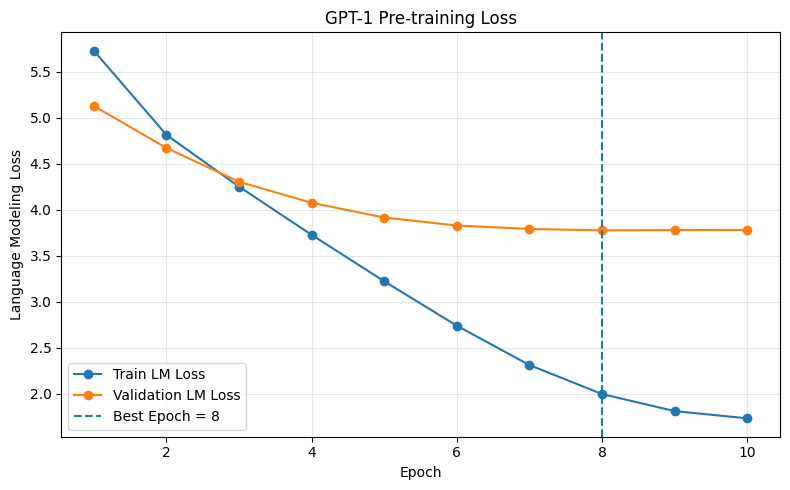

In [59]:
# ============================================================
# Step 10-1. Train / Validation LM Loss 시각화
# ============================================================

import matplotlib.pyplot as plt


epochs = range(
    1,
    len(history["train_loss"]) + 1
)


best_epoch_from_history = (
    int(
        np.argmin(
            history["val_loss"]
        )
    )
    + 1
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Train LM Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation LM Loss"
)

plt.axvline(
    best_epoch_from_history,
    linestyle="--",
    label=f"Best Epoch = {best_epoch_from_history}"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Language Modeling Loss"
)

plt.title(
    "GPT-1 Pre-training Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

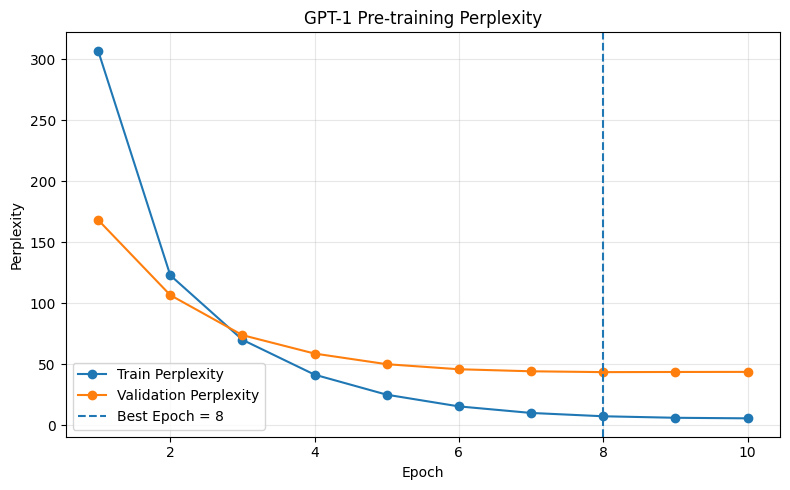

In [60]:
# ============================================================
# Step 10-2. Train / Validation Perplexity 시각화
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(
    epochs,
    history["train_ppl"],
    marker="o",
    label="Train Perplexity"
)

plt.plot(
    epochs,
    history["val_ppl"],
    marker="o",
    label="Validation Perplexity"
)


plt.axvline(
    best_epoch_from_history,
    linestyle="--",
    label=f"Best Epoch = {best_epoch_from_history}"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Perplexity"
)

plt.title(
    "GPT-1 Pre-training Perplexity"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [61]:
# ============================================================
# Step 10-3. Validation Loss 기준 Best Checkpoint 복원
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


model.eval()


print("=" * 70)
print("[Best GPT-1 Checkpoint]")

print(
    "Best Epoch   :",
    checkpoint["epoch"]
)

print(
    "Best Val Loss:",
    checkpoint["val_loss"]
)

print(
    "Best Val PPL :",
    checkpoint["val_ppl"]
)

print(
    "Checkpoint   :",
    BEST_MODEL_PATH
)

print("=" * 70)

[Best GPT-1 Checkpoint]
Best Epoch   : 8
Best Val Loss: 3.7739351262112493
Best Val PPL : 43.55110718192355
Checkpoint   : /content/drive/MyDrive/Colab Notebooks/Main_Quest_GPT1/models/main_quest_gpt1_best.pt


## Step 11. GPT-1 프롬프트 기반 텍스트 생성

기존 Encoder-Decoder 챗봇에서는 질문 전체를 Encoder에 입력하고,
Decoder가 Encoder의 representation을 Cross-Attention으로 참조하여 답변을 생성하였다.

이번 GPT-1 모델에는 Encoder와 Cross-Attention이 존재하지 않는다.

따라서 새로운 질문 역시 학습 당시 사용한 하나의 연속 sequence 형태로 변환한다.

예:

`질문 : 여행 가고 싶어 답변 :`

이 prompt 전체를 Decoder-only GPT-1에 입력하고,
마지막 위치의 vocabulary logits에서 다음 token 하나를 선택한다.

선택된 token을 다시 prompt 뒤에 붙인 뒤 같은 과정을 반복하여
EOS가 생성되거나 최대 context length에 도달할 때까지 autoregressive generation을 수행한다.

In [62]:
# ============================================================
# Step 11-1. GPT-1 Greedy Autoregressive Generation
# ============================================================

def generate_response(
    question,
    model,
    max_new_tokens=30
):
    """
    새로운 질문을 GPT-1 학습 당시와 같은 prompt 형식으로 변환하고,
    한 token씩 autoregressive하게 생성한다.

    ------------------------------------------------------------
    [기존 Transformer 챗봇과의 차이]
    ------------------------------------------------------------

    기존 EX09:
        Question → Encoder
        BOS → Decoder
        Cross-Attention으로 Question 참조

    이번 GPT-1:
        "질문 : Q 답변 :" 전체가 하나의 prompt

        Encoder 없음
        Cross-Attention 없음

        지금까지 등장한 모든 이전 token을 context로 사용하여
        다음 token을 하나씩 생성한다.
    ------------------------------------------------------------
    """

    model.eval()


    # --------------------------------------------------------
    # 1. 학습 당시와 동일한 dialogue prefix 구성
    # --------------------------------------------------------

    clean_question = normalize_text(
        question
    )

    prompt = (
        f"질문 : {clean_question} "
        f"답변 :"
    )


    # --------------------------------------------------------
    # 2. SentencePiece Encoding
    #
    # Generation 시작 prompt에는 EOS를 넣지 않는다.
    # EOS는 모델이 직접 생성해야 한다.
    # --------------------------------------------------------

    prompt_ids = sp.encode(
        prompt,
        out_type=int
    )


    generated_ids = []


    # --------------------------------------------------------
    # 3. Autoregressive Generation
    # --------------------------------------------------------

    for _ in range(
        max_new_tokens
    ):

        current_ids = (
            prompt_ids
            + generated_ids
        )


        # Learned Position Embedding의 최대 범위는 44이다.
        if len(current_ids) >= MAX_POSITIONS:
            break


        input_tensor = torch.tensor(
            [current_ids],
            dtype=torch.long,
            device=DEVICE
        )


        # Generation 중에는 PAD가 없으므로 모두 실제 token
        attention_mask = torch.ones_like(
            input_tensor,
            dtype=torch.bool
        )


        with torch.no_grad():

            output = model(
                input_ids=input_tensor,
                attention_mask=attention_mask
            )


        logits = output["logits"]


        # ----------------------------------------------------
        # 현재 sequence의 마지막 위치에서
        # 다음 token vocabulary score를 가져온다.
        #
        # [1, T, 8000]
        #       ↓
        # [8000]
        # ----------------------------------------------------

        next_token_logits = (
            logits[
                0,
                -1
            ]
        )


        # ----------------------------------------------------
        # Greedy Decoding
        #
        # 가장 높은 logit의 token 하나 선택
        # ----------------------------------------------------

        next_token_id = (
            torch.argmax(
                next_token_logits
            )
            .item()
        )


        # EOS가 나오면 생성 종료
        if next_token_id == EOS_ID:
            break


        generated_ids.append(
            next_token_id
        )


    # --------------------------------------------------------
    # 4. 생성된 "답변 부분"만 decode
    # --------------------------------------------------------

    response = sp.decode(
        generated_ids
    ).strip()


    return {
        "question": clean_question,
        "prompt": prompt,
        "generated_ids": generated_ids,
        "response": response
    }

In [63]:
# ============================================================
# Step 11-2. 새로운 질문에 대한 생성 결과 확인
# ============================================================

test_questions = [
    "안녕?",
    "땡큐우~",
    "오늘 너무 습하다",
    "친구랑 안 싸웠음",
    "여행 잘 다녀왔음",
    "좋아하는 사람 질문 좀 그만하자?",
]


for question in test_questions:

    result = generate_response(
        question=question,
        model=model,
        max_new_tokens=30
    )


    print("=" * 80)

    print(
        "Q:",
        result["question"]
    )

    print(
        "Prompt:",
        result["prompt"]
    )

    print(
        "A:",
        result["response"]
    )

Q: 안녕?
Prompt: 질문 : 안녕? 답변 :
A: 잘 견뎌봐요.
Q: 땡큐우~
Prompt: 질문 : 땡큐우~ 답변 :
A: 저도 해보고 싶네요.
Q: 오늘 너무 습하다
Prompt: 질문 : 오늘 너무 습하다 답변 :
A: 좋은 생각 하지 마세요.
Q: 친구랑 안 싸웠음
Prompt: 질문 : 친구랑 안 싸웠음 답변 :
A: 사람 고쳐쓰는 거 아니에요.
Q: 여행 잘 다녀왔음
Prompt: 질문 : 여행 잘 다녀왔음 답변 :
A: 좋은 생각이에요.
Q: 좋아하는 사람 질문 좀 그만하자?
Prompt: 질문 : 좋아하는 사람 질문 좀 그만하자? 답변 :
A: 마음이 복잡할 수 있어요.


| 입력                 | 생성              | 내 평가                                   |
| ------------------ | --------------- | ------------------------------------ |
| 안녕?                | 잘 견뎌봐요.         | 한국어 문장은 자연스럽지만 인사 맥락은 약함             |
| 땡큐우~               | 저도 해보고 싶네요.     | 문법적 생성은 성공, 의미 연결은 약함                |
| 오늘 너무 습하다          | 좋은 생각 하지 마세요.   | 의미적으로 부적절                            |
| 친구랑 안 싸웠음          | 사람 고쳐쓰는 거 아니에요. | 대인관계 표현은 연결되지만 **부정 표현 ‘안’의 의미를 놓침** |
| 여행 잘 다녀왔음          | 좋은 생각이에요.       | 약하게 관련되지만 정확한 반응은 아님                 |
| 좋아하는 사람 질문 좀 그만하자? | 마음이 복잡할 수 있어요.  | 비교적 맥락에 맞음                           |


### 생성 결과 해석

Best checkpoint인 Epoch 8 모델에 학습 데이터에 직접 포함되지 않은 표현을 prompt로 입력하여
Greedy Autoregressive Generation을 수행함.

모든 입력에서 한국어 형태의 출력이 생성되었으며,
모델이 학습한 `"질문 : ... 답변 :"` 구조를 이용하여
Decoder-only 방식의 next-token generation이 정상적으로 동작함을 확인했다.

일부 출력에서는 질문과 의미적으로 연결되는 답변이 생성되었다.

예:
- `좋아하는 사람 질문 좀 그만하자?`
  → `마음이 복잡할 수 있어요.`

반면 다음과 같이 문법적으로는 자연스럽지만 입력 맥락과 연결이 약한 사례도 확인되었다.

- `안녕?`
  → `잘 견뎌봐요.`
- `오늘 너무 습하다`
  → `좋은 생각 하지 마세요.`

또한:

- `친구랑 안 싸웠음`
  → `사람 고쳐쓰는 거 아니에요.`

에서는 관계·갈등과 관련된 표현에는 반응했으나,
`안`이라는 부정 표현으로 인해 달라지는 전체 문장 의미를 충분히 반영하지 못했다.

따라서 본 모델은 한국어의 문장 형태와 상담형 대화 패턴,
causal autoregressive generation 방식은 학습하였으나
새로운 입력의 세부 의미에 맞는 답변을 안정적으로 생성하는 데에는 한계가 있다.

본 실험은 GPT-1의 supervised fine-tuning 단계가 아니라
causal language modeling 기반 pre-training까지만을 대상으로 하므로,
생성 결과는 downstream task 성능보다
사전학습된 Decoder-only 언어모델의 정상 동작 여부를 확인하는 정성 평가로 사용했다......